# Inferencia estadística
Gran parte del curso pasaremos hablando de inferencia estadística. Esta nos permite comprobar supuestos de los datos, analizar datos tomando en cuenta la incertidumbre de los datos, etc. 

## Distribuciones muestrales


En primer lugar, es necesario denotar los siguientes conceptos:

> **Estimador puntual**
> La **estimación puntual** de un parámetro poblacional $\theta$ es un valor singular $\hat{\theta}$ de un estadístico $\widehat{\Theta}$. El estadístico $\widehat{\Theta}$ corresponde al **estimador puntual**.

Aunque no lo vimos como tal, la media muestral y la varianza muestral son estimadores puntuales para la media poblacional y varianza poblacional. 

Una propiedad clave de los estimadores puntuales es el **sesgo**. 
> **Sesgo de un estimador puntual**
> Dado el estimador puntual $\widehat{\Theta}$ para el parámetro poblacional $\theta$, si
> $$\mathbb{E}[\widehat{\Theta}] = \theta$$
> Se dice que $\widehat{\Theta}$ es un estimador **insesgado** de $\theta$. En el caso contrario
> $$\mathbb{E}[\widehat{\Theta}] - \theta$$
> Es el sesgo del estimador $\widehat{\Theta}$.

Esta propiedad la poseen la media muestral y la varianza muestral, pero no la desviación estándar muestral. 

Notemos que los valores de los estimadores puntales corresponden a variables aleatorias. Esto quiere decir que, si desde una misma población se obtienen dos muestras, la estimación puntual para $\theta$ desde cada muestra $\theta_1$ y $\theta_2$ puede ser diferente, mas estas vienen de una misma distribución. Esta propiedad garantiza que, si bien no necesariamente son iguales, vienen de una distribución caracterizable. 

### Teorema del Límite Central
El teorema del límite central permite caracterizar la distribución muestral de la media muestral. Este es uno de los teoremas más importantes del área de probabilidad. 
> **Teorema del Límite Central**
> Si $X_1, X_2, ..., X_n$$ es una muestra aleatoria de tamaño n de una población descrita por una media $\mu$ y varianza $\sigma^2$, y si $\overline{X}$ corresponde a la media muestral, la distribución límite de 
> $$ Z = \frac{\overline{X} - \mu}{\sigma/\sqrt{n}} $$
> cuando $n\to\infty$, es una distribución normal con media 0 y varianza 1.

Mediante propiedades de las distribuciones normales, este teorema tambien garantiza que la distribución muestral de la media es $\overline{X}\sim \mathcal{N}(\mu, \sigma^2/n)$. 

La cantidad $\sigma/\sqrt{n}$ se denomina *error estándar* y denota la desviación estándar de la distribución muestral de la media.

Una aplicación de este teorema es que, a medida que aumenta el tamaño de $n$, es posible obtener una distribución muestral más acotada.

En el siguiente código se verá este teorema en acción.

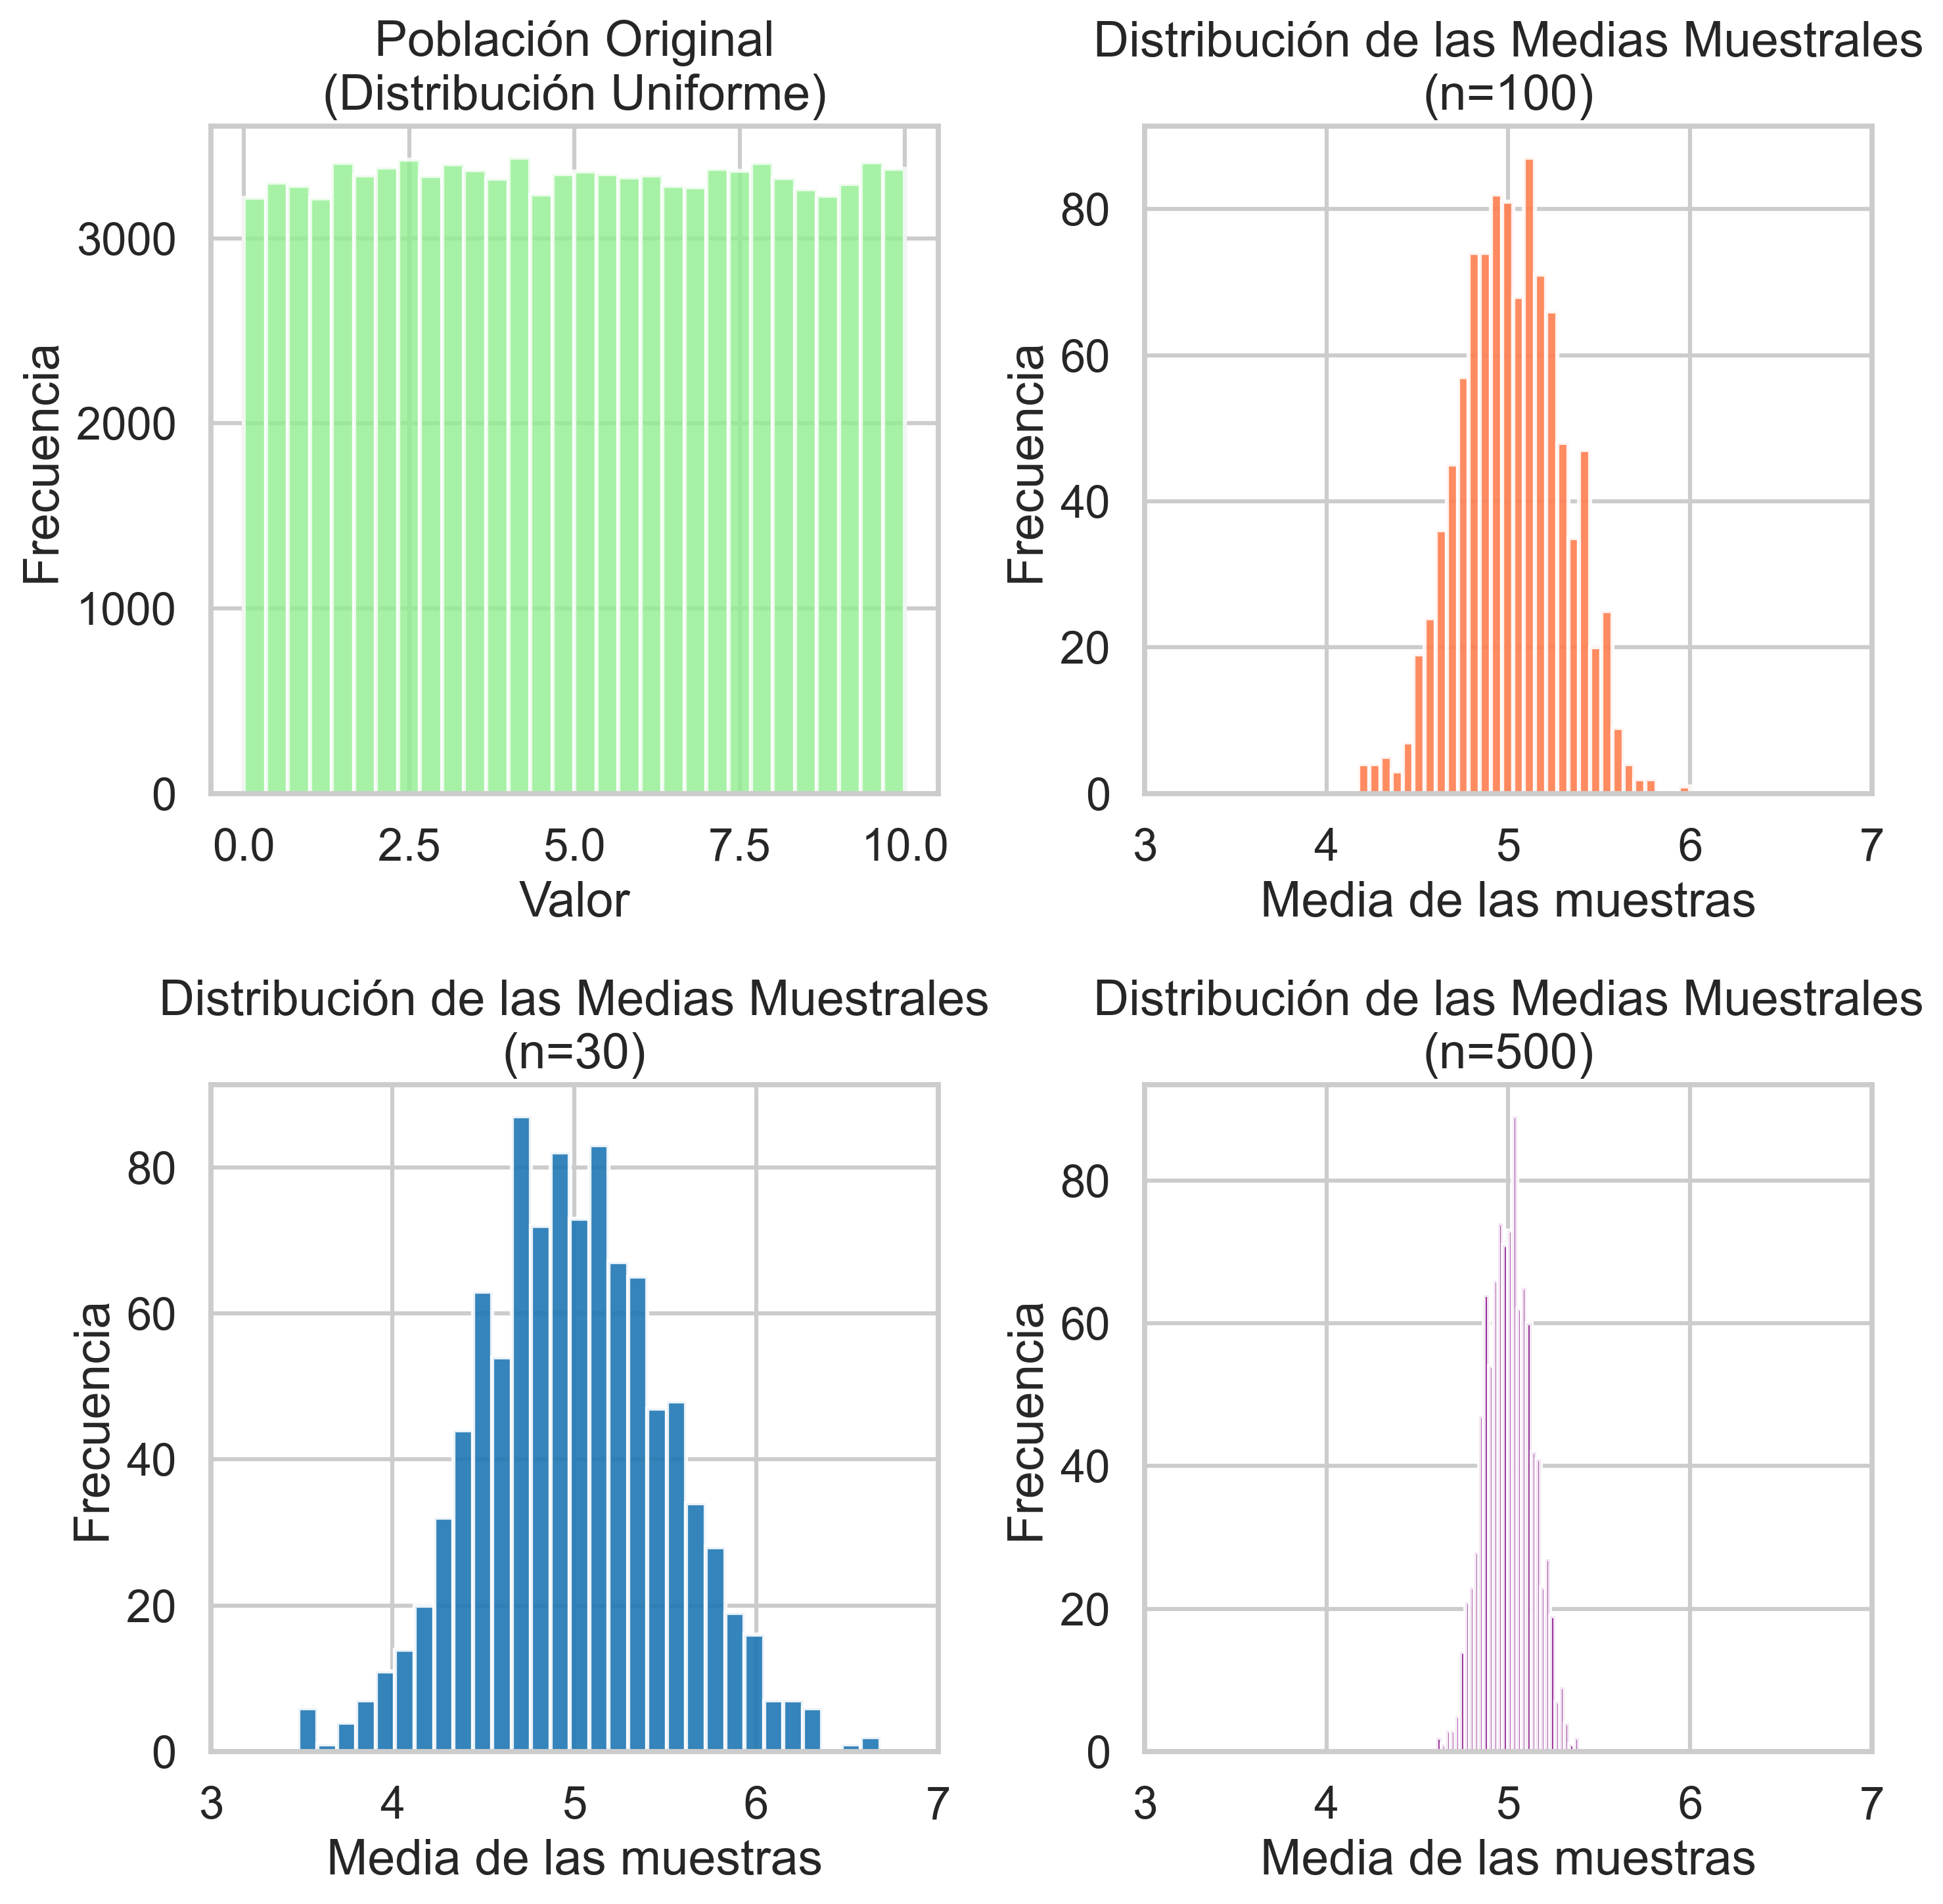

In [51]:

# Definimos una población original con una distribución CLARAMENTE NO NORMAL
# En este caso, usaremos una distribución uniforme (plana)
poblacion_no_normal = np.random.uniform(0, 10, 100000)

# Parámetros para el muestreo
n_muestras = 1000  # Cantidad de muestras a extraer
tamano_muestra = 30  # Tamaño n de cada pequeña muestra

medias_muestrales_30 = []

# Extraemos 'n_muestras' de tamaño 'tamano_muestra' y calculamos la media de cada una
for _ in range(n_muestras):
    muestra_temporal = np.random.choice(poblacion_no_normal, tamano_muestra)
    media_temporal = np.mean(muestra_temporal)
    medias_muestrales_30.append(media_temporal)

tamano_muestra = 100  # Tamaño n de cada pequeña muestra
medias_muestrales_100 = []
# Extraemos 'n_muestras' de tamaño 'tamano_muestra' y calculamos la media de cada una
for _ in range(n_muestras):
    muestra_temporal = np.random.choice(poblacion_no_normal, tamano_muestra)
    media_temporal = np.mean(muestra_temporal)
    medias_muestrales_100.append(media_temporal)
    
tamano_muestra = 500  # Tamaño n de cada pequeña muestra
medias_muestrales_500 = []      
for _ in range(n_muestras):
    muestra_temporal = np.random.choice(poblacion_no_normal, tamano_muestra)
    media_temporal = np.mean(muestra_temporal)
    medias_muestrales_500.append(media_temporal)

# Visualizamos la población original vs. la distribución de las medias
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300)

# La población original
axes[0,0].hist(poblacion_no_normal, bins=30, color='lightgreen', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Población Original\n(Distribución Uniforme)')
axes[0,0].set_xlabel('Valor')
axes[0,0].set_ylabel('Frecuencia')

# Las medias muestrales con n=30
axes[1,0].hist(medias_muestrales_30, bins=30, color='tab:blue', edgecolor='white', alpha=0.9)
axes[1,0].set_title(f'Distribución de las Medias Muestrales\n(n=30)')
axes[1,0].set_xlabel('Media de las muestras')
axes[1,0].set_xlim(3, 7)  # Limitar el eje x para mejor visualización
axes[1,0].set_ylabel('Frecuencia')

# Las medias muestrales con n=100
axes[0,1].hist(medias_muestrales_100, bins=30, color='coral', edgecolor='white', alpha=0.9)
axes[0,1].set_title(f'Distribución de las Medias Muestrales\n(n=100)')
axes[0,1].set_xlabel('Media de las muestras')
axes[0,1].set_xlim(3, 7)  # Limitar el eje x para mejor visualización
axes[0,1].set_ylabel('Frecuencia')

# Las medias muestrales con n=500
axes[1,1].hist(medias_muestrales_500, bins=30, color='purple', edgecolor='white', alpha=0.9)
axes[1,1].set_title(f'Distribución de las Medias Muestrales\n(n=500)')
axes[1,1].set_xlabel('Media de las muestras')
axes[1,1].set_xlim(3, 7)  # Limitar el eje x para mejor visualización
axes[1,1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Podemos notar que la distribución muestral, a medida que aumenta el tamaño de muestra, se hace más acotada y le da más densidad a los valores cercanos a la media. 
> ⚠️ OJITO
> El $n$ de el Teorema del Límite Central hace referencia a la cantidad de datos tomados desde la población. En el gráfico anterior se utilizaron 5, 30, 100 y 500 puntos por muestra. Esto no hace referencia a las 1000 muestras tomadas, estas 1000 muestras tomadas hace referencia a cuantas veces se muestreo la población.

Ahora verifiquemos que la matemática del Teorema del límite central se cumple, es decir, que las distribuciones muestrales en realidad distribuyan $\overline{X}\sim \mathcal{N}(\mu, \sigma^2/n)$.

El TLC nos dice que además de acercarse a una distribución normal, la distribución de la media muestral tendrá características heredadas de la población original:
- La **media esperada** de las medias muestrales ($\mu_{\bar{x}}$) será igual a la media de la población original ($\mu$).
- La **desviación estándar esperada** de las medias muestrales, también conocida como *error estándar de la media* ($\sigma_{\bar{x}}$), será la desviación estándar de la población ($\sigma$) dividida por la raíz cuadrada del tamaño de la muestra ($\sqrt{n}$).


In [52]:
# Definir características teóricas de la población Uniforme(0, 10)
mu_poblacion = 5.0 # Punto medio entre 0 y 10
varianza_poblacion = (10 - 0)**2 / 12 # Varianza dada la distribución Uniforme(a,b) = (b-a)^2 / 12
sigma_poblacion = np.sqrt(varianza_poblacion)

# Propiedades que deberían tener las muestras según el TLC n = 30
mu_teorica_30 = mu_poblacion
sigma_teorica_error_30 = sigma_poblacion / np.sqrt(30) # sigma / sqrt(n)
media_empirica_30 = np.mean(medias_muestrales_30)
std_empirica_30 = np.std(medias_muestrales_30, ddof=1)

print("=== Comparación de Estadísticos para n=30 ===")
print(f"Media teórica esperada (TLC): {mu_teorica_30:.4f}")
print(f"Media empírica de nuestro muestreo: {media_empirica_30:.4f}")
print(f"Desv. Estándar teórica esperada (TLC): {sigma_teorica_error_30:.4f}")
print(f"Desv. Estándar (Error Estándar) empírica: {std_empirica_30:.4f}")

# Repetimos el mismo proceso para n=100
mu_teorica_100 = mu_poblacion
sigma_teorica_error_100 = sigma_poblacion / np.sqrt(100) # sigma / sqrt(n)
media_empirica_100 = np.mean(medias_muestrales_100)
std_empirica_100 = np.std(medias_muestrales_100, ddof=1)
print("\n=== Comparación de Estadísticos para n=100 ===")
print(f"Media teórica esperada (TLC): {mu_teorica_100:.4f}")
print(f"Media empírica de nuestro muestreo: {media_empirica_100:.4f}")
print(f"Desv. Estándar teórica esperada (TLC): {sigma_teorica_error_100:.4f}")
print(f"Desv. Estándar (Error Estándar) empírica: {std_empirica_100:.4f}")

# Repetimos el mismo proceso para n=500
mu_teorica_500 = mu_poblacion
sigma_teorica_error_500 = sigma_poblacion / np.sqrt(500) # sigma / sqrt(n)
media_empirica_500 = np.mean(medias_muestrales_500)
std_empirica_500 = np.std(medias_muestrales_500, ddof=1)
print("\n=== Comparación de Estadísticos para n=500 ===")
print(f"Media teórica esperada (TLC): {mu_teorica_500:.4f}")
print(f"Media empírica de nuestro muestreo: {media_empirica_500:.4f}")
print(f"Desv. Estándar teórica esperada (TLC): {sigma_teorica_error_500:.4f}")
print(f"Desv. Estándar (Error Estándar) empírica: {std_empirica_500:.4f}")


=== Comparación de Estadísticos para n=30 ===
Media teórica esperada (TLC): 5.0000
Media empírica de nuestro muestreo: 4.9932
Desv. Estándar teórica esperada (TLC): 0.5270
Desv. Estándar (Error Estándar) empírica: 0.5226

=== Comparación de Estadísticos para n=100 ===
Media teórica esperada (TLC): 5.0000
Media empírica de nuestro muestreo: 5.0199
Desv. Estándar teórica esperada (TLC): 0.2887
Desv. Estándar (Error Estándar) empírica: 0.2837

=== Comparación de Estadísticos para n=500 ===
Media teórica esperada (TLC): 5.0000
Media empírica de nuestro muestreo: 5.0044
Desv. Estándar teórica esperada (TLC): 0.1291
Desv. Estándar (Error Estándar) empírica: 0.1301


Otro tipo de gráficos que se pueden utilizar en este caso son los denominados QQ-plots. Los qq-plots son típicamente usados para verificar normalidad en los datos, pero en realidad se pueden usar para verificar que los datos siguen cualquier distribución.

Text(0.5, 1.0, 'Gráfico Q-Q de las Medias Muestrales (n=30)')

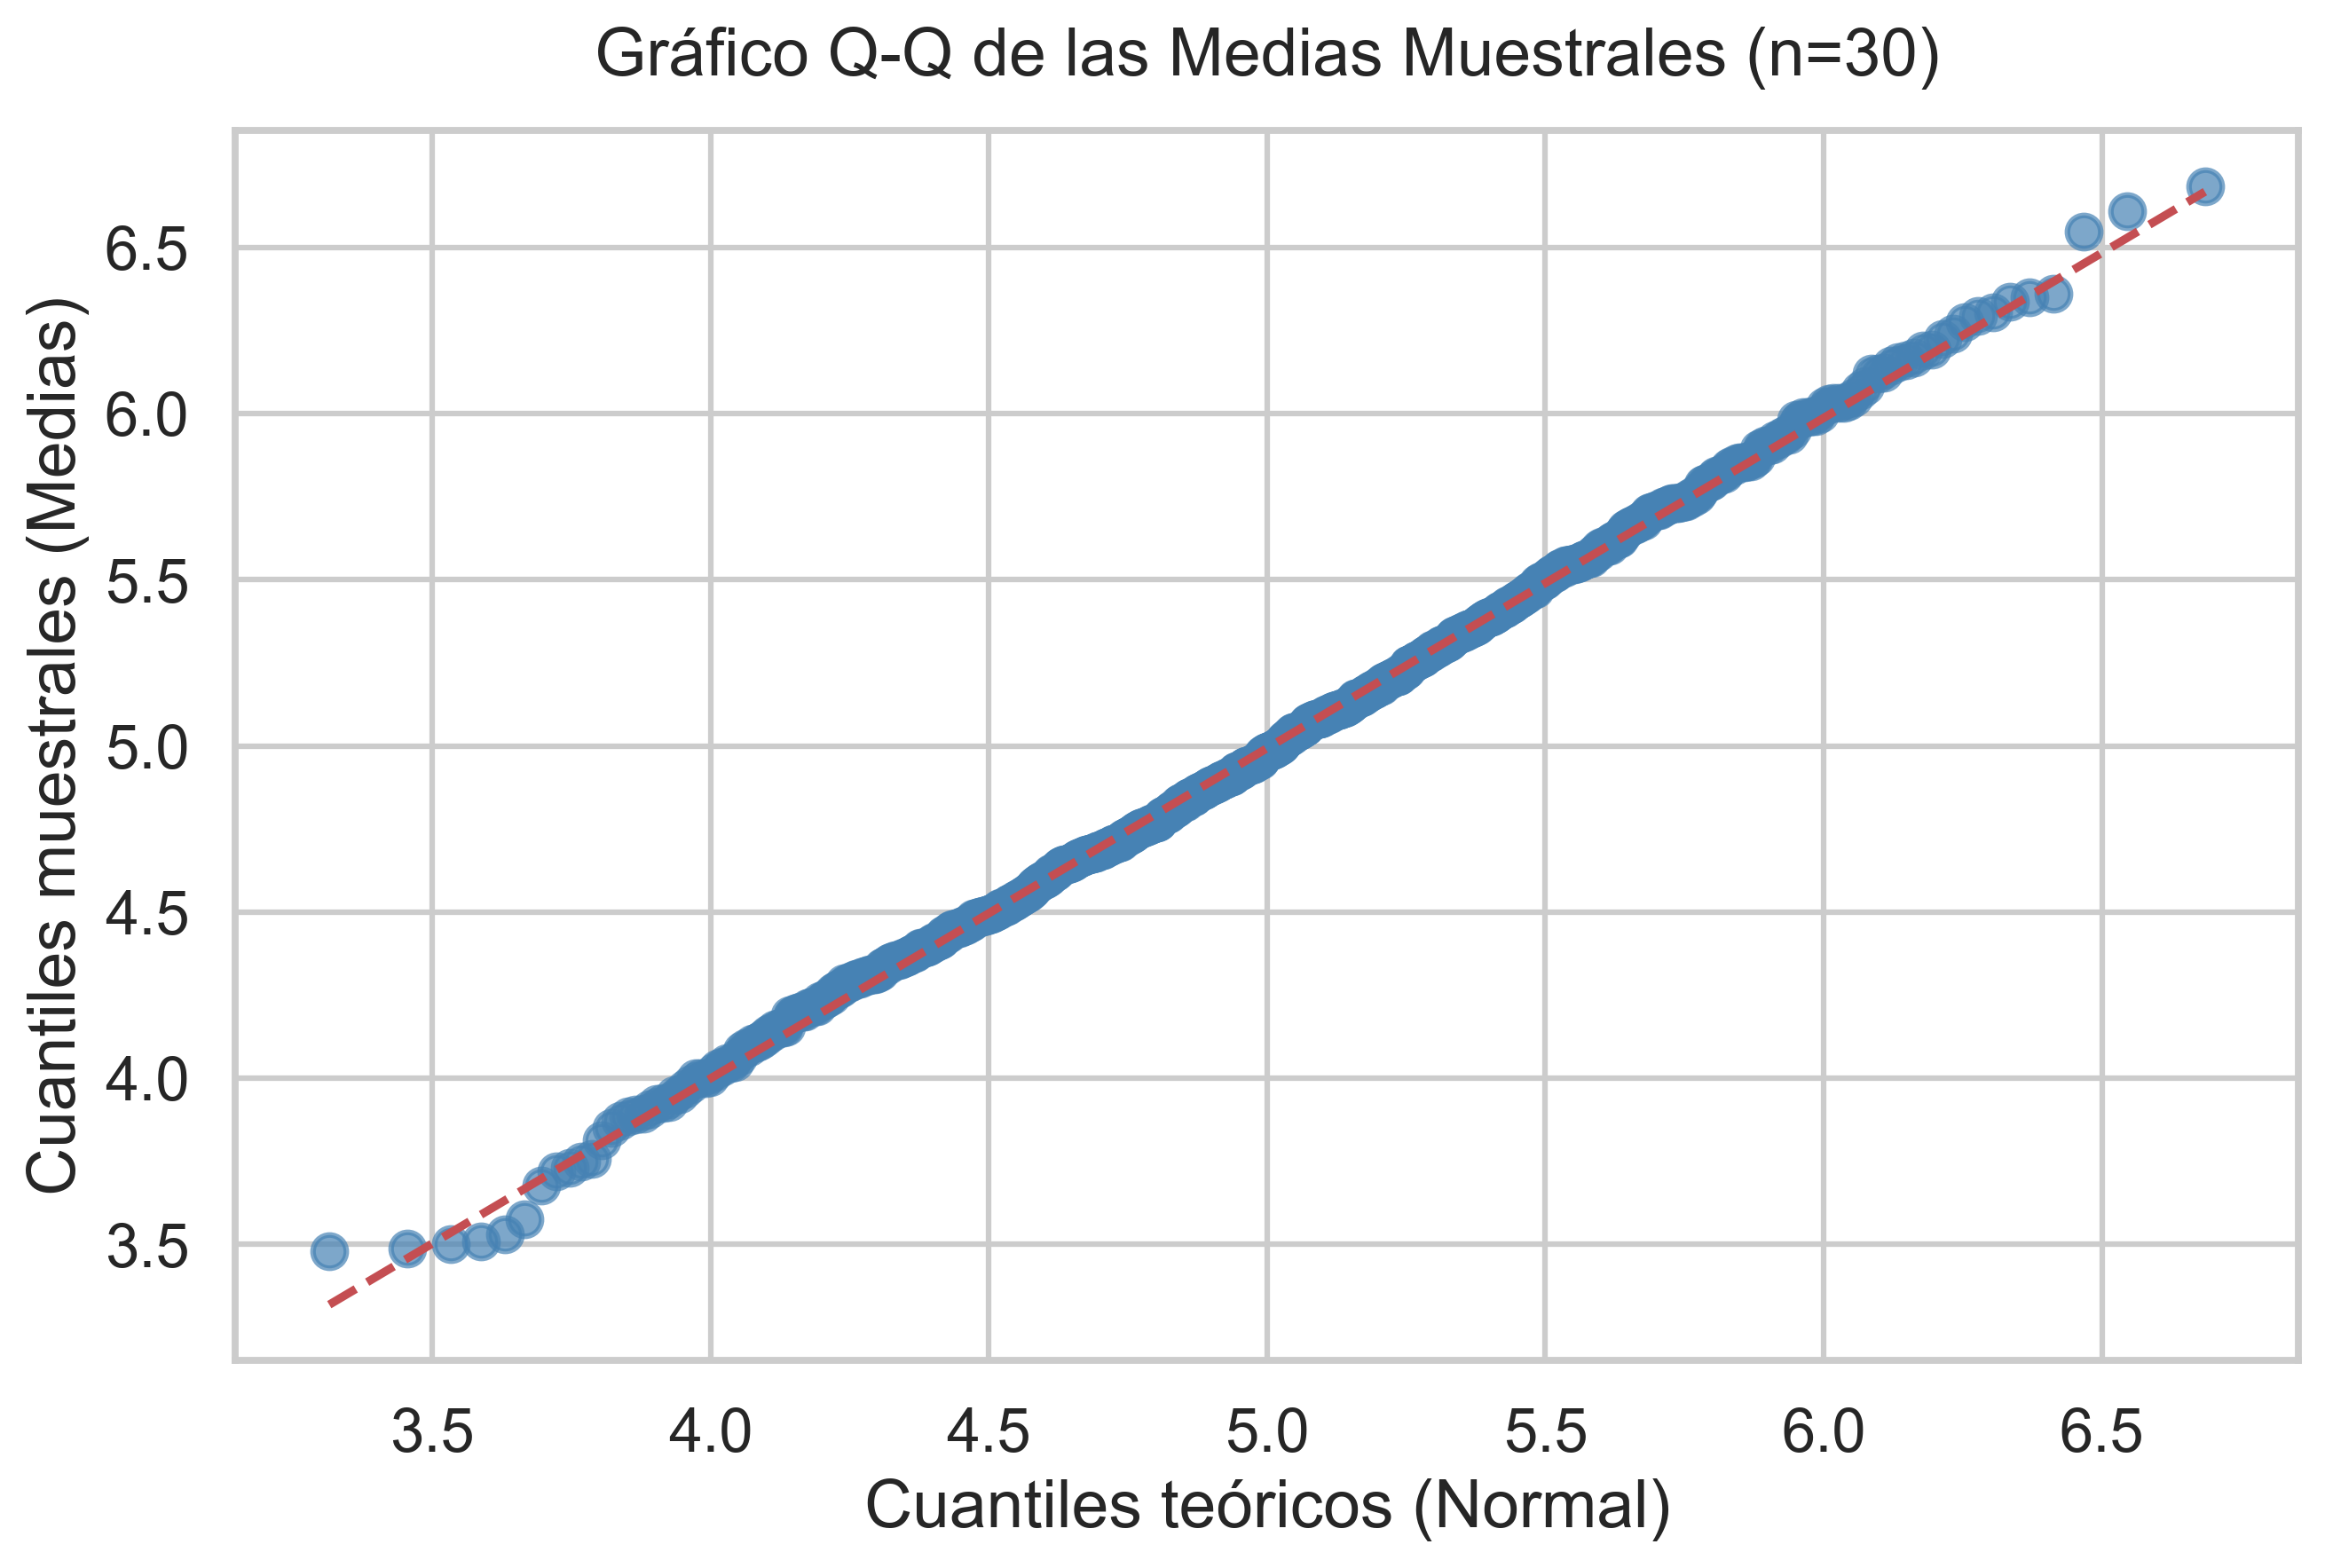

In [53]:
# para el tamaño de muestra n=30
desviacion_teorica = sigma_poblacion / np.sqrt(30)
media_teorica = mu_poblacion
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
(osm, osr), (slope, intercept, r) = stats.probplot(medias_muestrales_30, # datos a graficar
                                          dist="norm", # distribución teórica a comparar (Normal)
                                          sparams=(media_teorica, desviacion_teorica) # parámetros de la distribución Normal (media y desviación estándar)
                                          )
ax.scatter(osm, osr, # osm: ordenados teóricos, osr: ordenados muestrales 
        color='steelblue', alpha=0.7, label='Datos de las medias muestrales') 
ax.plot(osm, slope*osm + intercept, # 
        'r--')
ax.set_xlabel('Cuantiles teóricos (Normal)')
ax.set_ylabel('Cuantiles muestrales (Medias)')
ax.set_title('Gráfico Q-Q de las Medias Muestrales (n=30)', pad=15)

Text(0.5, 1.0, 'Gráfico Q-Q de las Medias Muestrales (n=100)')

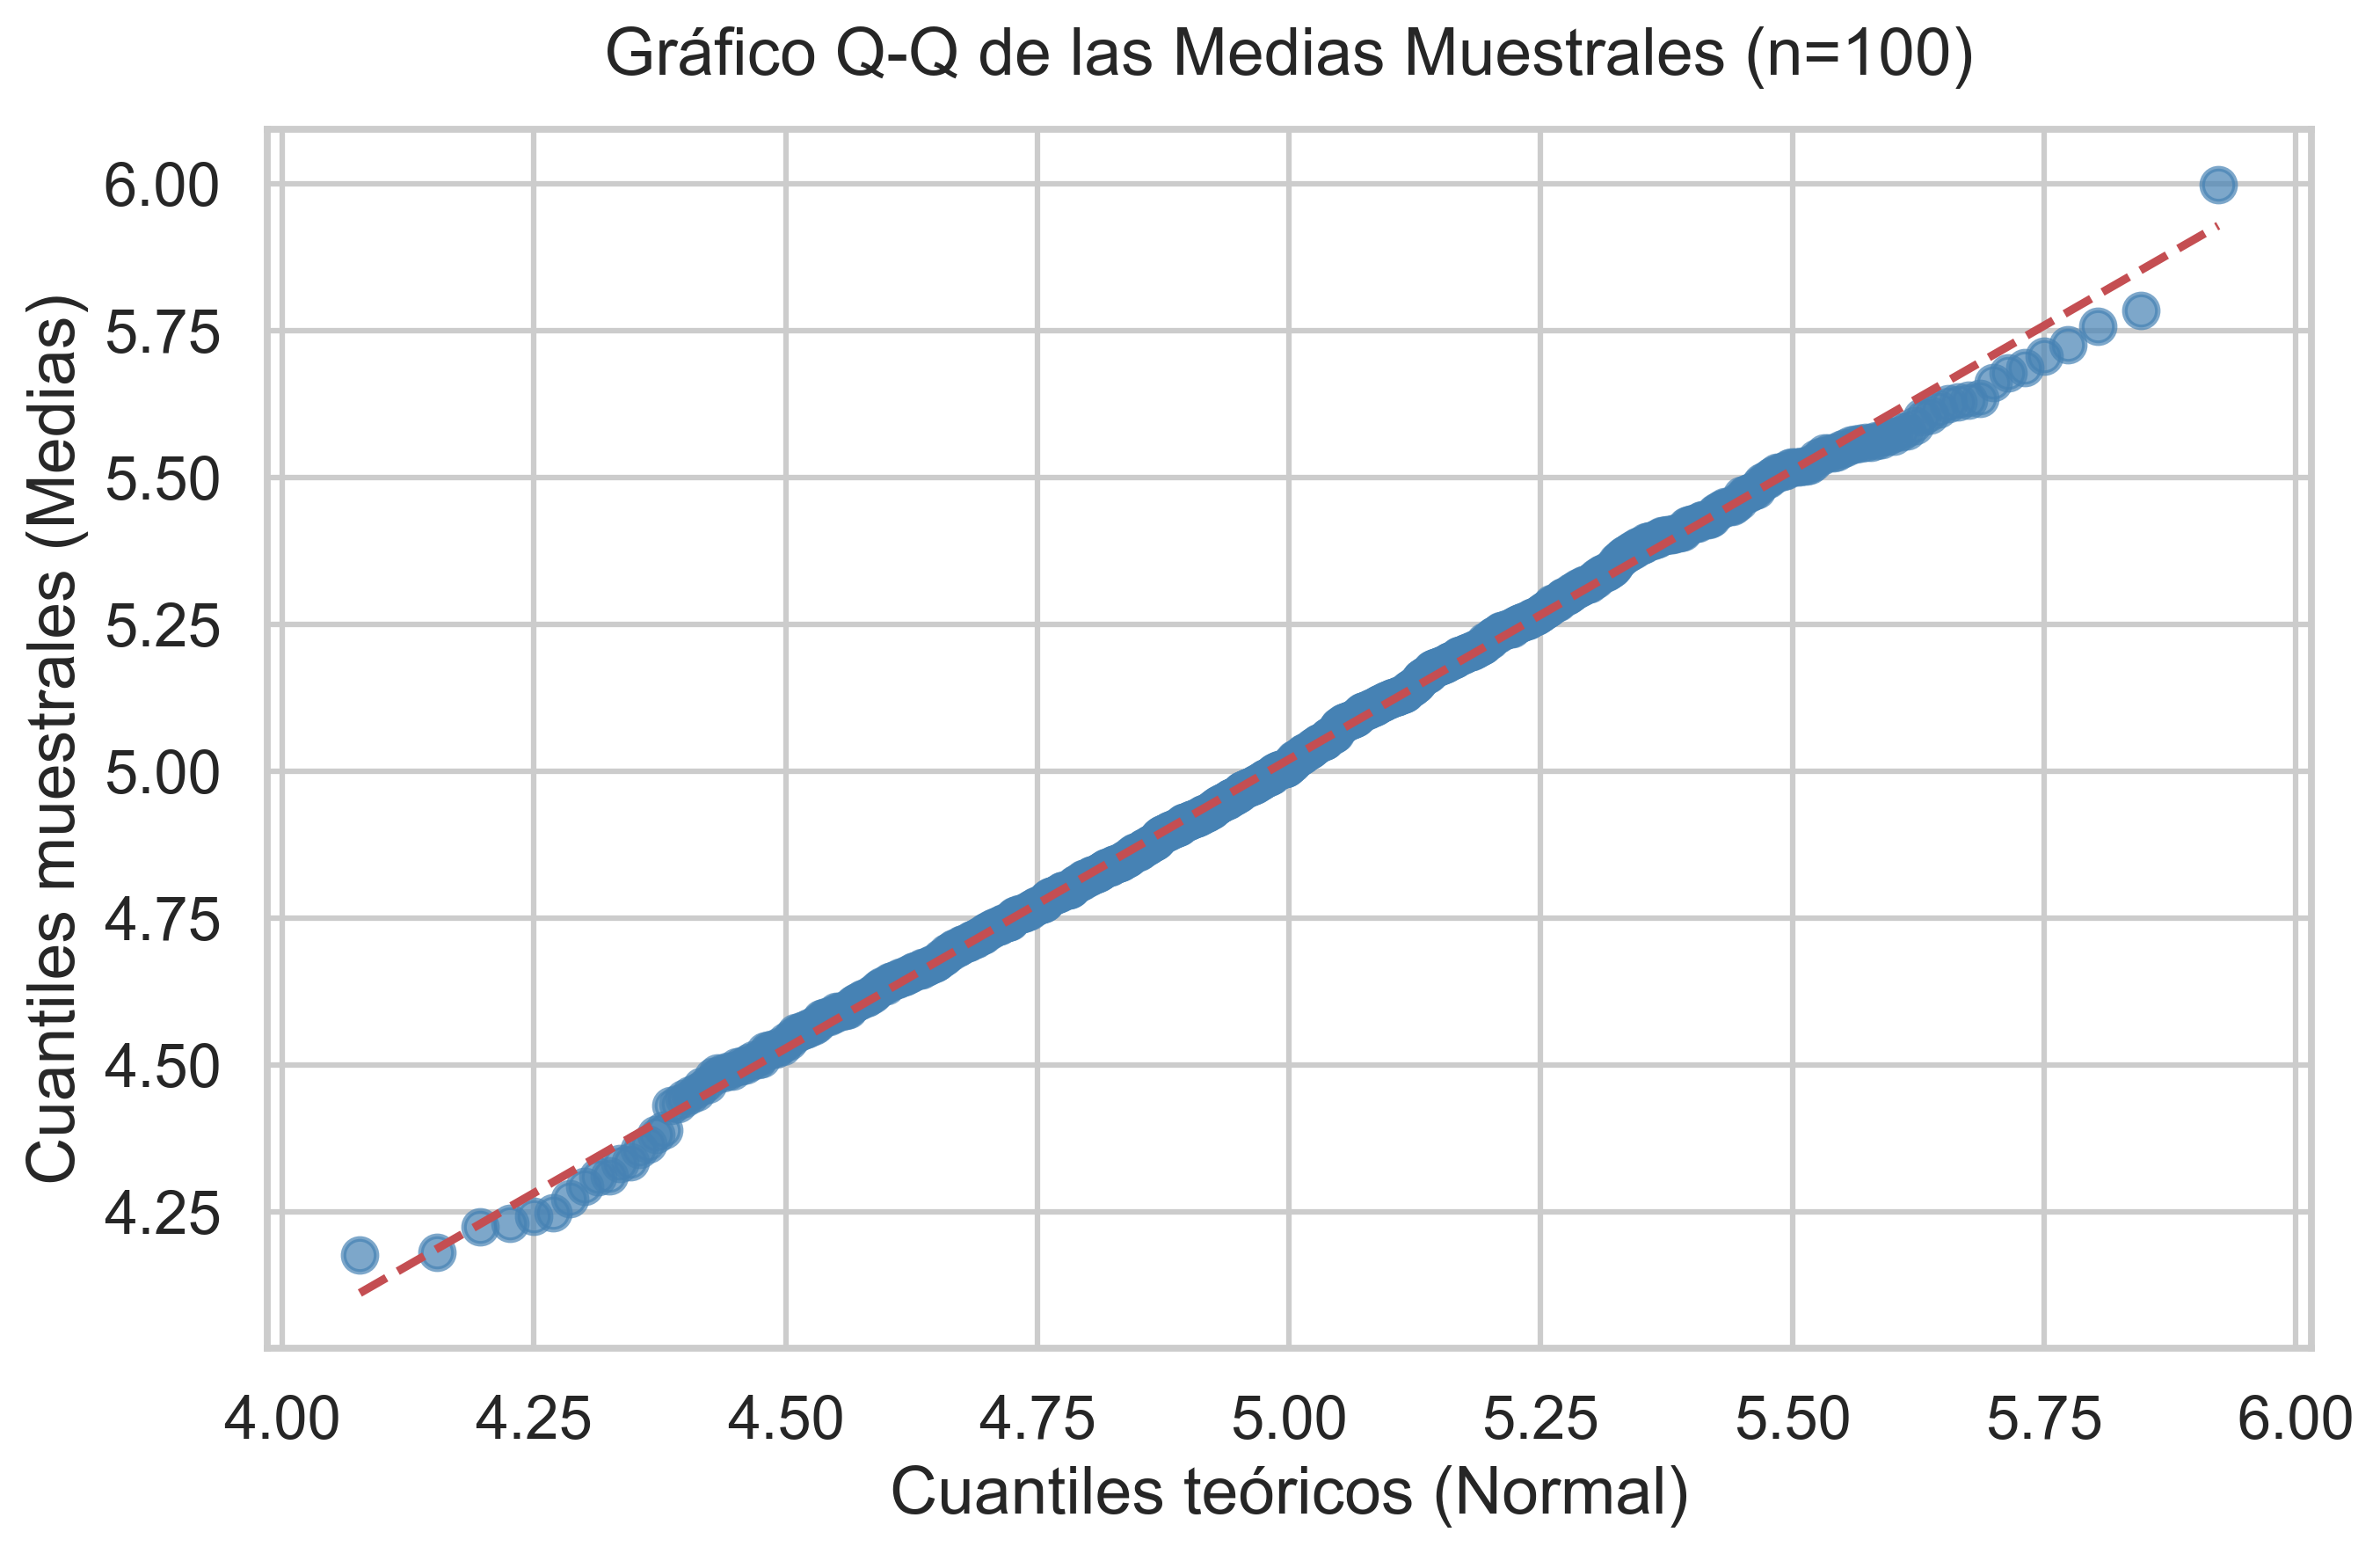

In [54]:
# -------------------------
# para el tamaño de muestra n=100
desviacion_teorica = sigma_poblacion / np.sqrt(100)
media_teorica = mu_poblacion
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
(osm, osr), (slope, intercept, r) = stats.probplot(medias_muestrales_100, # datos a graficar
                                          dist="norm", # distribución teórica a comparar (Normal)
                                          sparams=(media_teorica, desviacion_teorica) # parámetros de la distribución Normal (media y desviación estándar)
                                          )
ax.scatter(osm, osr, # osm: ordenados teóricos, osr: ordenados muestrales 
        color='steelblue', alpha=0.7, label='Datos de las medias muestrales') 
ax.plot(osm, slope*osm + intercept, # 
        'r--')
ax.set_xlabel('Cuantiles teóricos (Normal)')
ax.set_ylabel('Cuantiles muestrales (Medias)')
ax.set_title('Gráfico Q-Q de las Medias Muestrales (n=100)', pad=15)

Text(0.5, 1.0, 'Gráfico Q-Q de las Medias Muestrales (n=500)')

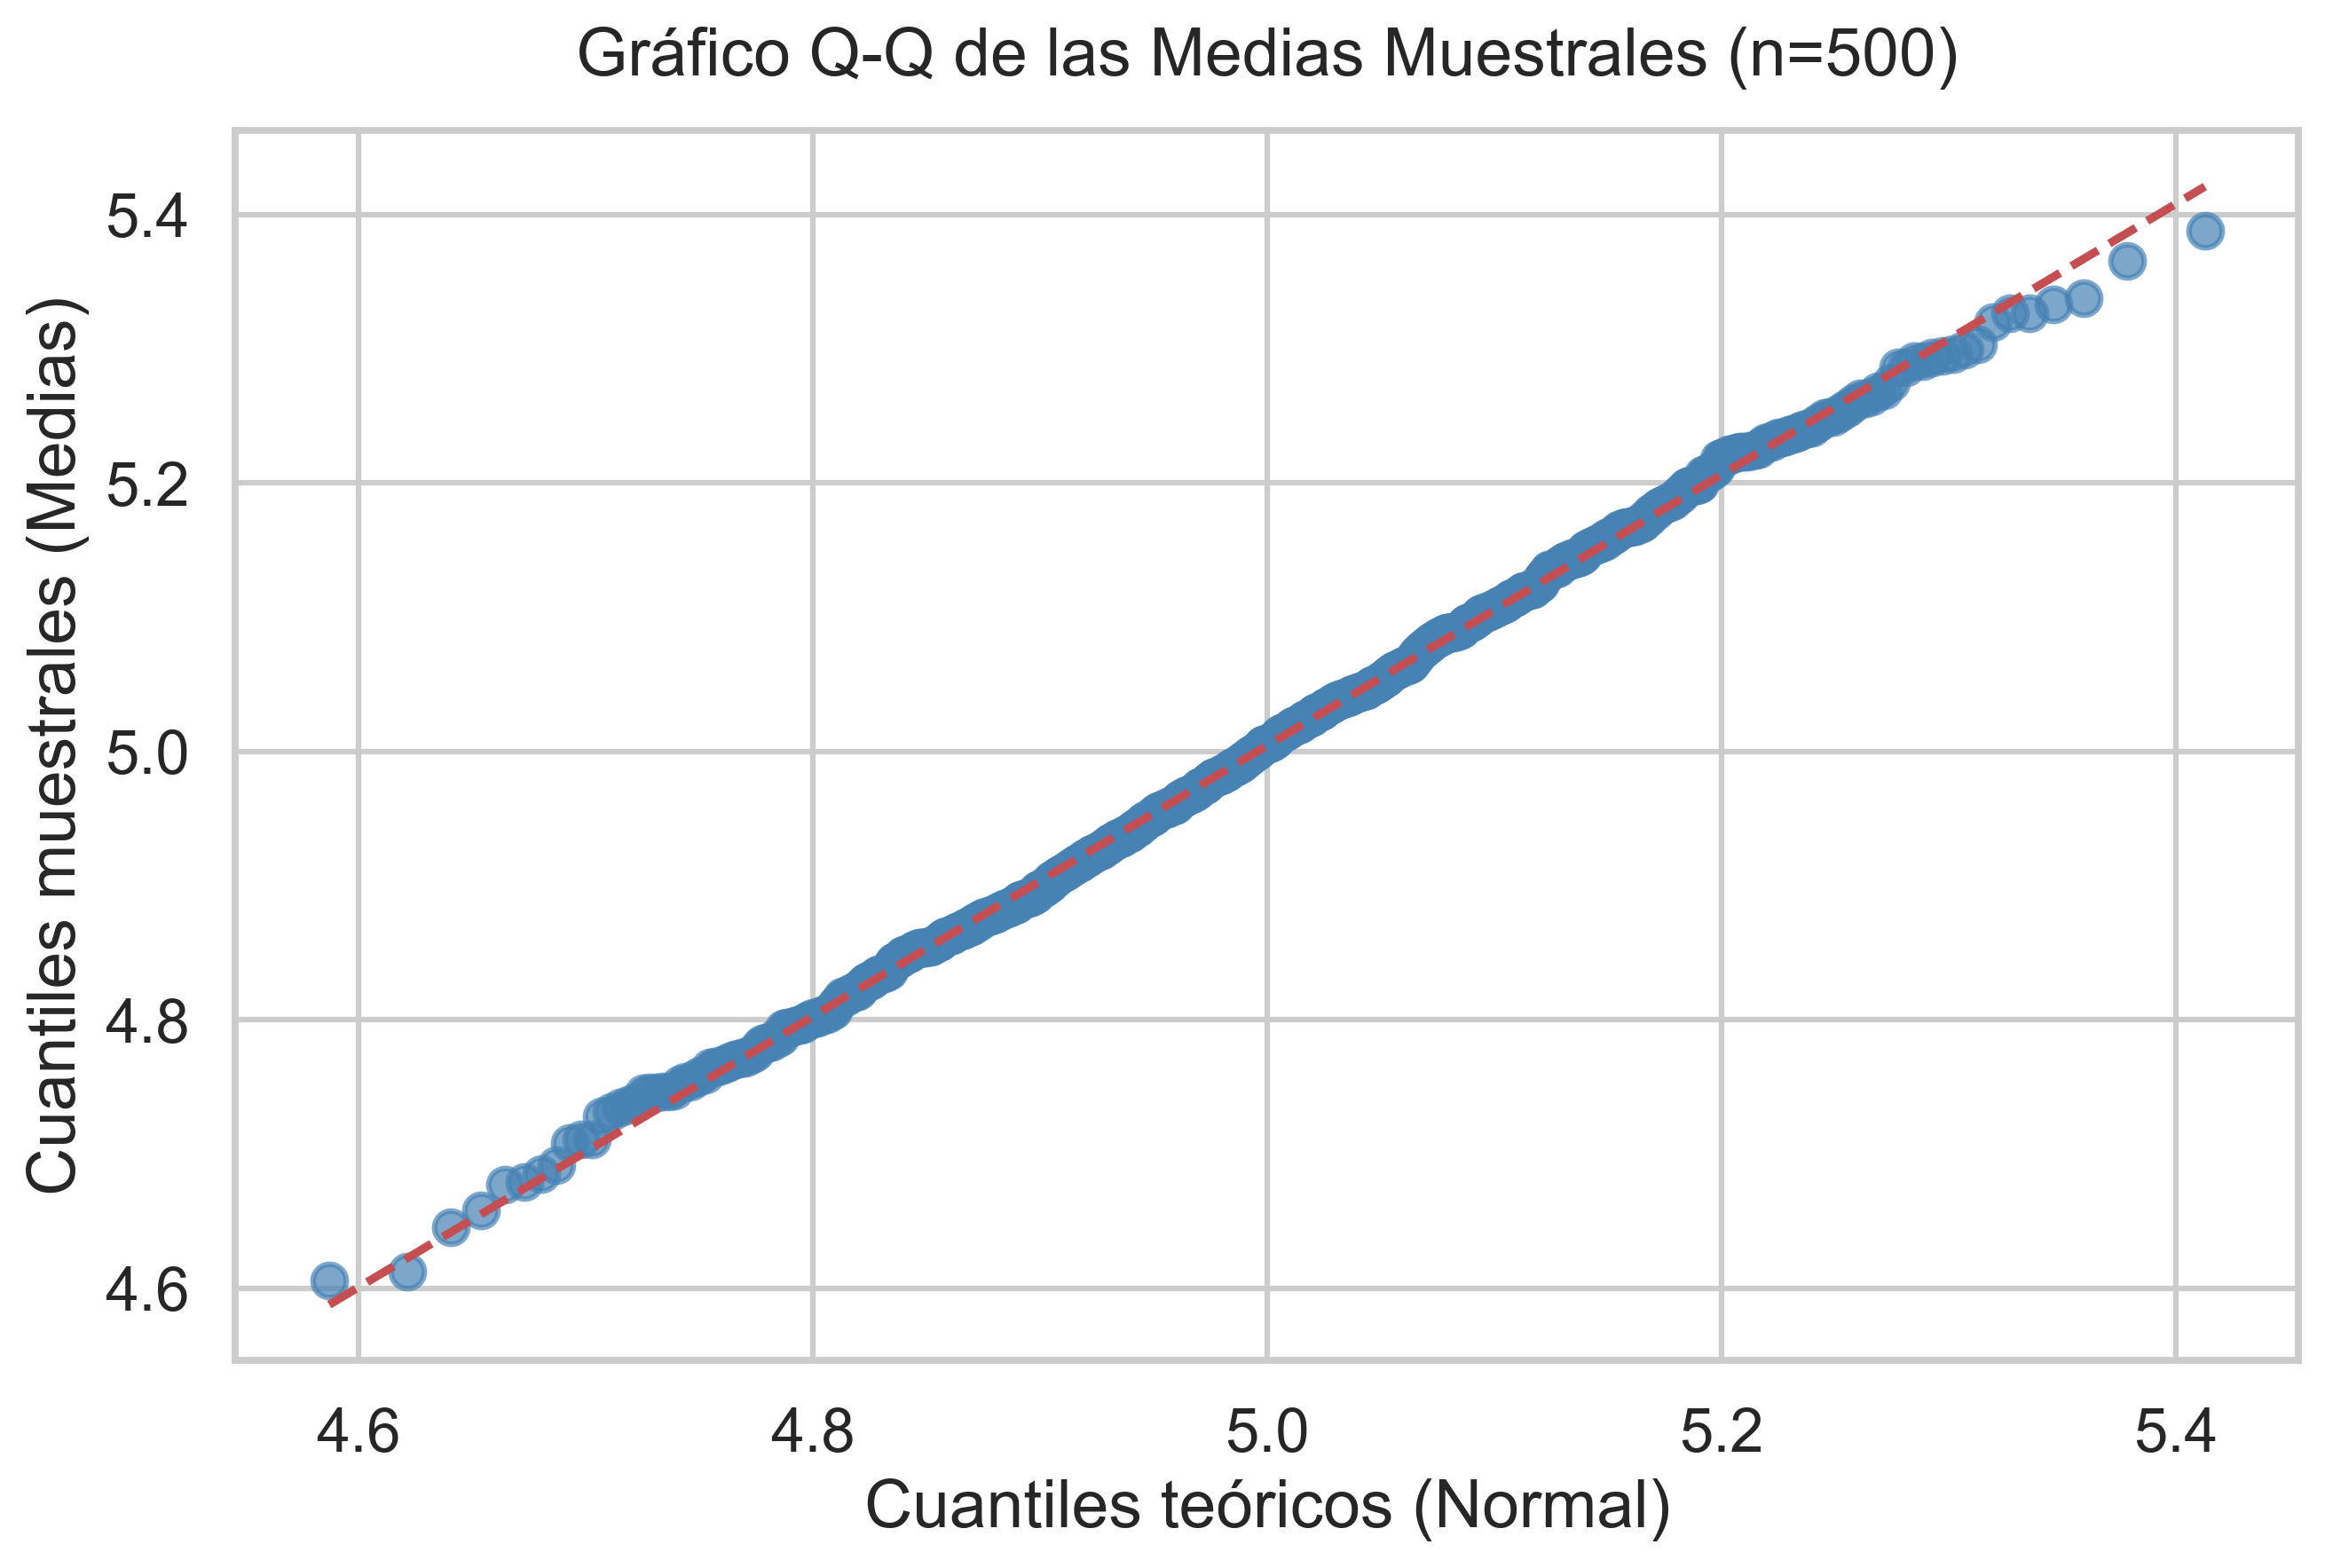

In [55]:
# -------------------------
# para el tamaño de muestra n=500
desviacion_teorica = sigma_poblacion / np.sqrt(500)
media_teorica = mu_poblacion
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
(osm, osr), (slope, intercept, r) = stats.probplot(medias_muestrales_500, # datos a graficar
                                          dist="norm", # distribución teórica a comparar (Normal)
                                          sparams=(media_teorica, desviacion_teorica) # parámetros de la distribución Normal (media y desviación estándar)
                                          )
ax.scatter(osm, osr, # osm: ordenados teóricos, osr: ordenados muestrales 
        color='steelblue', alpha=0.7, label='Datos de las medias muestrales') 
ax.plot(osm, slope*osm + intercept, # 
        'r--')
ax.set_xlabel('Cuantiles teóricos (Normal)')
ax.set_ylabel('Cuantiles muestrales (Medias)')
ax.set_title('Gráfico Q-Q de las Medias Muestrales (n=500)', pad=15)

Podemos ver, en los tres casos, que en los tres casos se cumple lo estipulado por el TLC.

> Side note:
> Los QQ-plots también permiten evaluar la forma de los datos. 

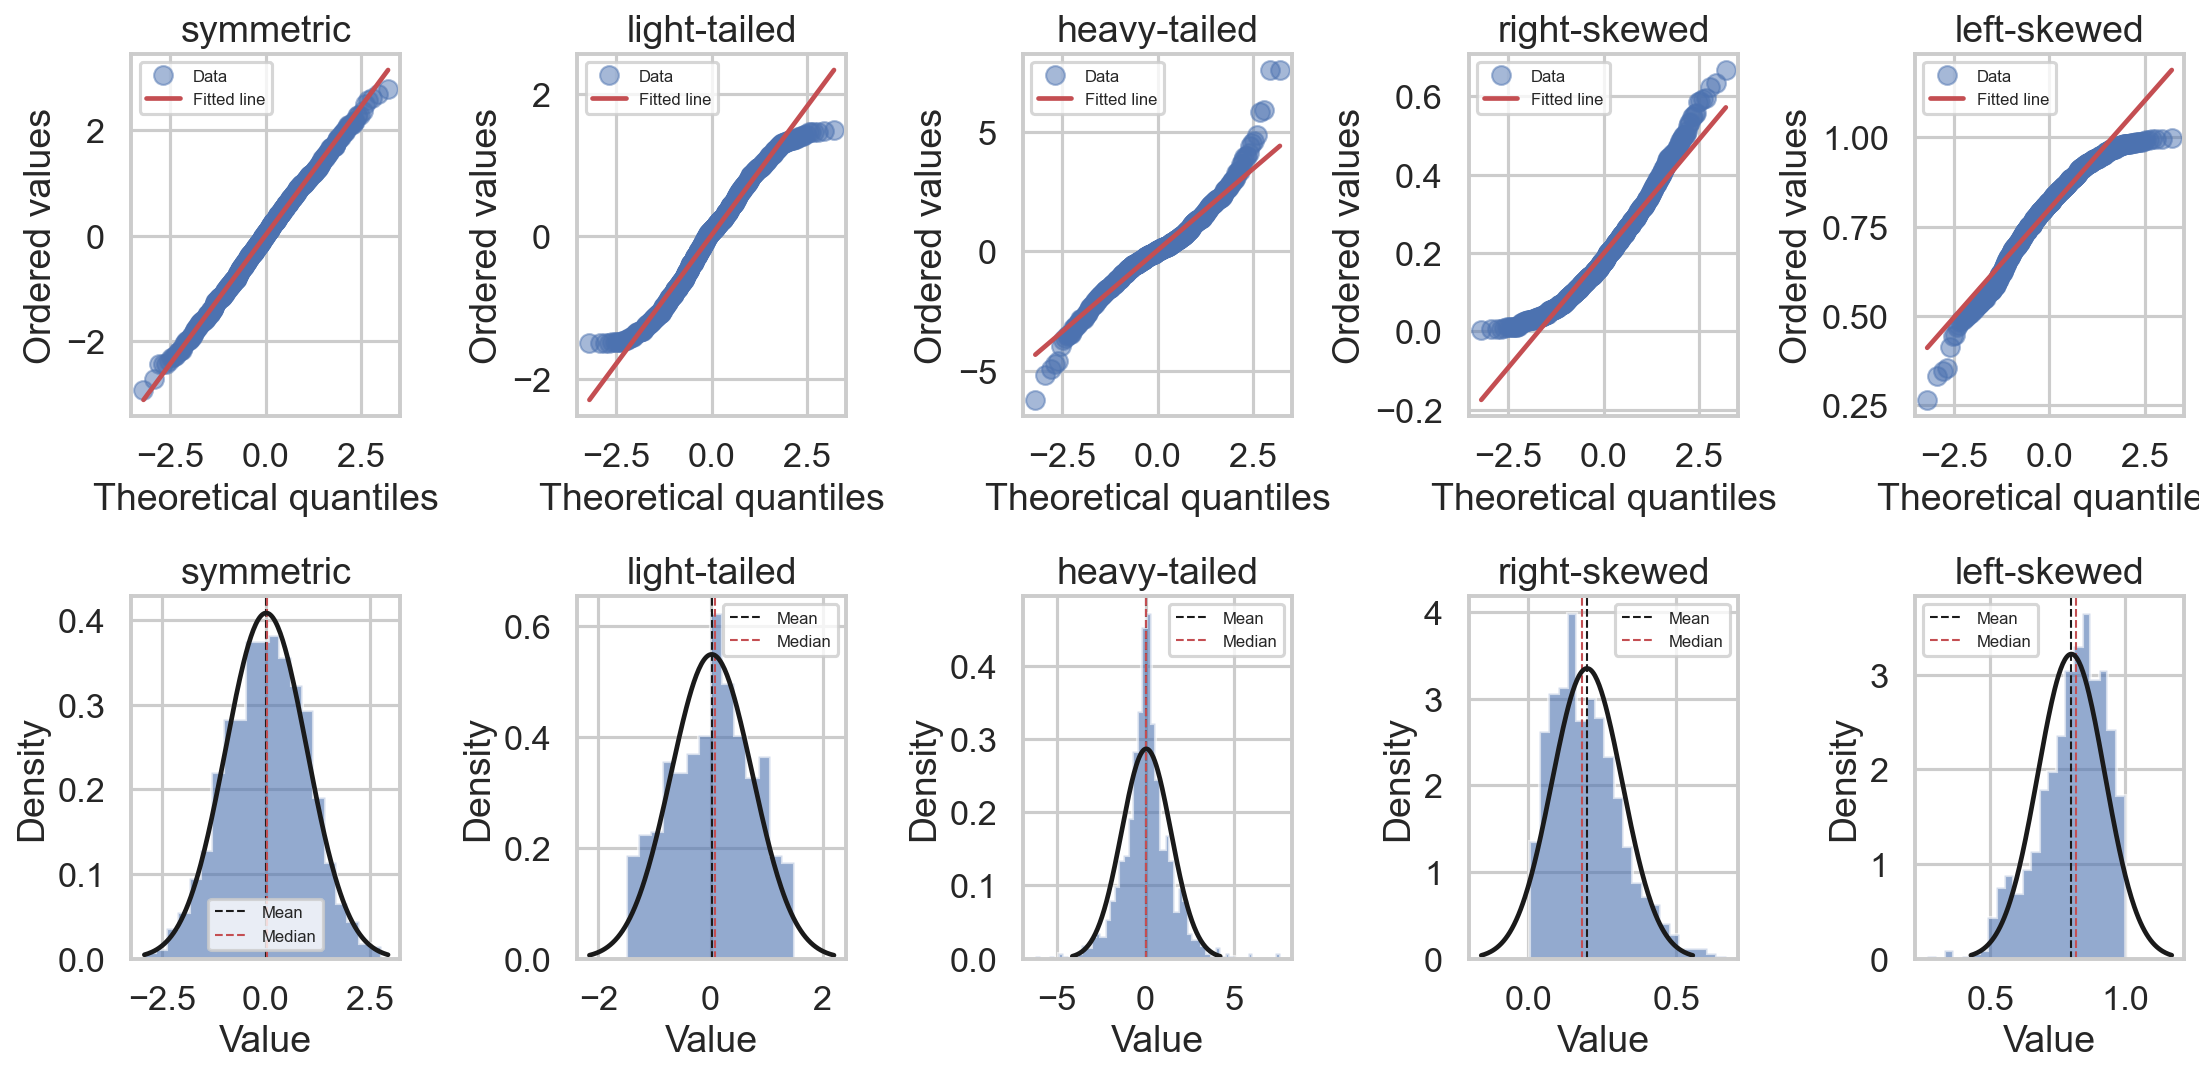

In [56]:
# QQ plot con scipy - distintas distribuciones

N = 1000
dists = {
    'symmetric': stats.norm(),
    'light-tailed': stats.truncnorm(-1.5, 1.5),
    'heavy-tailed': stats.laplace(),
    'right-skewed': stats.beta(2, 8),
    'left-skewed': stats.beta(8, 2)
}

# 2 filas (QQ + hist) x 5 columnas (una por distribucion)
fig, axs = plt.subplots(2, len(dists), figsize=(15, 7.5), dpi=150)

for col, (name, dist) in enumerate(dists.items()):
    x = dist.rvs(N)

    # QQ plot contra normal estandar
    (osm, osr), (slope, intercept, r) = stats.probplot(x, dist='norm')
    axs[0, col].plot(osm, osr, 'o', alpha=0.5, label='Data')
    axs[0, col].plot(osm, slope * osm + intercept, 'r-', label='Fitted line')
    axs[0, col].set_title(name)
    axs[0, col].set_xlabel('Theoretical quantiles')
    axs[0, col].set_ylabel('Ordered values')
    axs[0, col].legend(fontsize=8)

    # Histograma + ajuste normal con media/desviacion de la muestra
    mean = x.mean()
    median = np.median(x)
    axs[1, col].hist(x, density=True, bins='auto', histtype='stepfilled', alpha=0.6)
    xgrid = np.linspace(x.mean() - x.std() * 3, x.mean() + x.std() * 3, 200)
    axs[1, col].axvline(mean, color='k', linestyle='dashed', linewidth=1, label='Mean')
    axs[1, col].axvline(median, color='r', linestyle='dashed', linewidth=1, label='Median')
    axs[1, col].plot(xgrid, stats.norm(loc=x.mean(), scale=x.std()).pdf(xgrid), 'k-')
    axs[1, col].set_title(name)
    axs[1, col].set_xlabel('Value')
    axs[1, col].set_ylabel('Density')
    axs[1, col].legend(fontsize=8)

plt.tight_layout()
plt.show()

Además del TLC aplicado para medias, es posible aplicarlo para diferencia muestral de medias:

> **Distribución Muestral Aproximada de la Diferencia de Medias Muestrales**
>
> Si tenemos dos poblaciones independientes con medias $\mu_1$ y $\mu_2$ y varianzas $\sigma_1^2$ y $\sigma_2^2$, y si $\bar{X}_1$ y $\bar{X}_2$ son las medias muestrales de dos muestras aleatorias independientes de tamaños $n_1$ y $n_2$ tomadas de estas poblaciones, entonces la distribución muestral de
>
> $$Z = \frac{\bar{X}_1 - \bar{X}_2 - (\mu_1 - \mu_2)}{\sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}}$$
>
> es aproximadamente normal estándar, si se cumplen las condiciones del teorema central del límite. Si ambas poblaciones son normales, la distribución muestral de $Z$ es exactamente normal estándar.

## Intervalos de confianza

Los intervalos de confianza son intervalos, de ahí el nombre, que contienen a un parámetro poblacional con cierta probabilidad. Es importante notar que, cuando hablamos del intervalo de confianza de un $100(1-\alpha)\%$ hace referencia a que ese intervalo, encapsula de forma correcta el parámetro $\theta$ con una confianza de $100(1-\alpha)\%$. 

### Intervalo de confianza para la media

El intervalo de confianza para la media viene dado por la siguiente definición:

> **Intervalo de Confianza para la Media, Varianza Conocida**
>
> Si $\bar{x}$ es la media muestral de una muestra aleatoria de tamaño $n$ proveniente de una población normal con varianza conocida $\sigma^2$, un IC del $100(1-\alpha)\%$ para $\mu$ está dado por
>
> $$\bar{x} - z_{\alpha/2}\,\sigma/\sqrt{n} \leq \mu \leq \bar{x} + z_{\alpha/2}\,\sigma/\sqrt{n}$$
>
> donde $z_{\alpha/2}$ es el percentil superior $100\alpha/2$ de la distribución normal estándar.

Notar que es NECESARIO conocer la media poblacional. De esta forma:
$$
P(\bar{x} - z_{\alpha/2}\,\sigma/\sqrt{n} \leq \mu \leq \bar{x} + z_{\alpha/2}\,\sigma/\sqrt{n}) = 1-\alpha
$$

Notemos también que estos intervalos son variables aleatorias. 

Text(0.5, 1.0, 'Intervalos de Confianza para la Media (std poblacional conocido)')

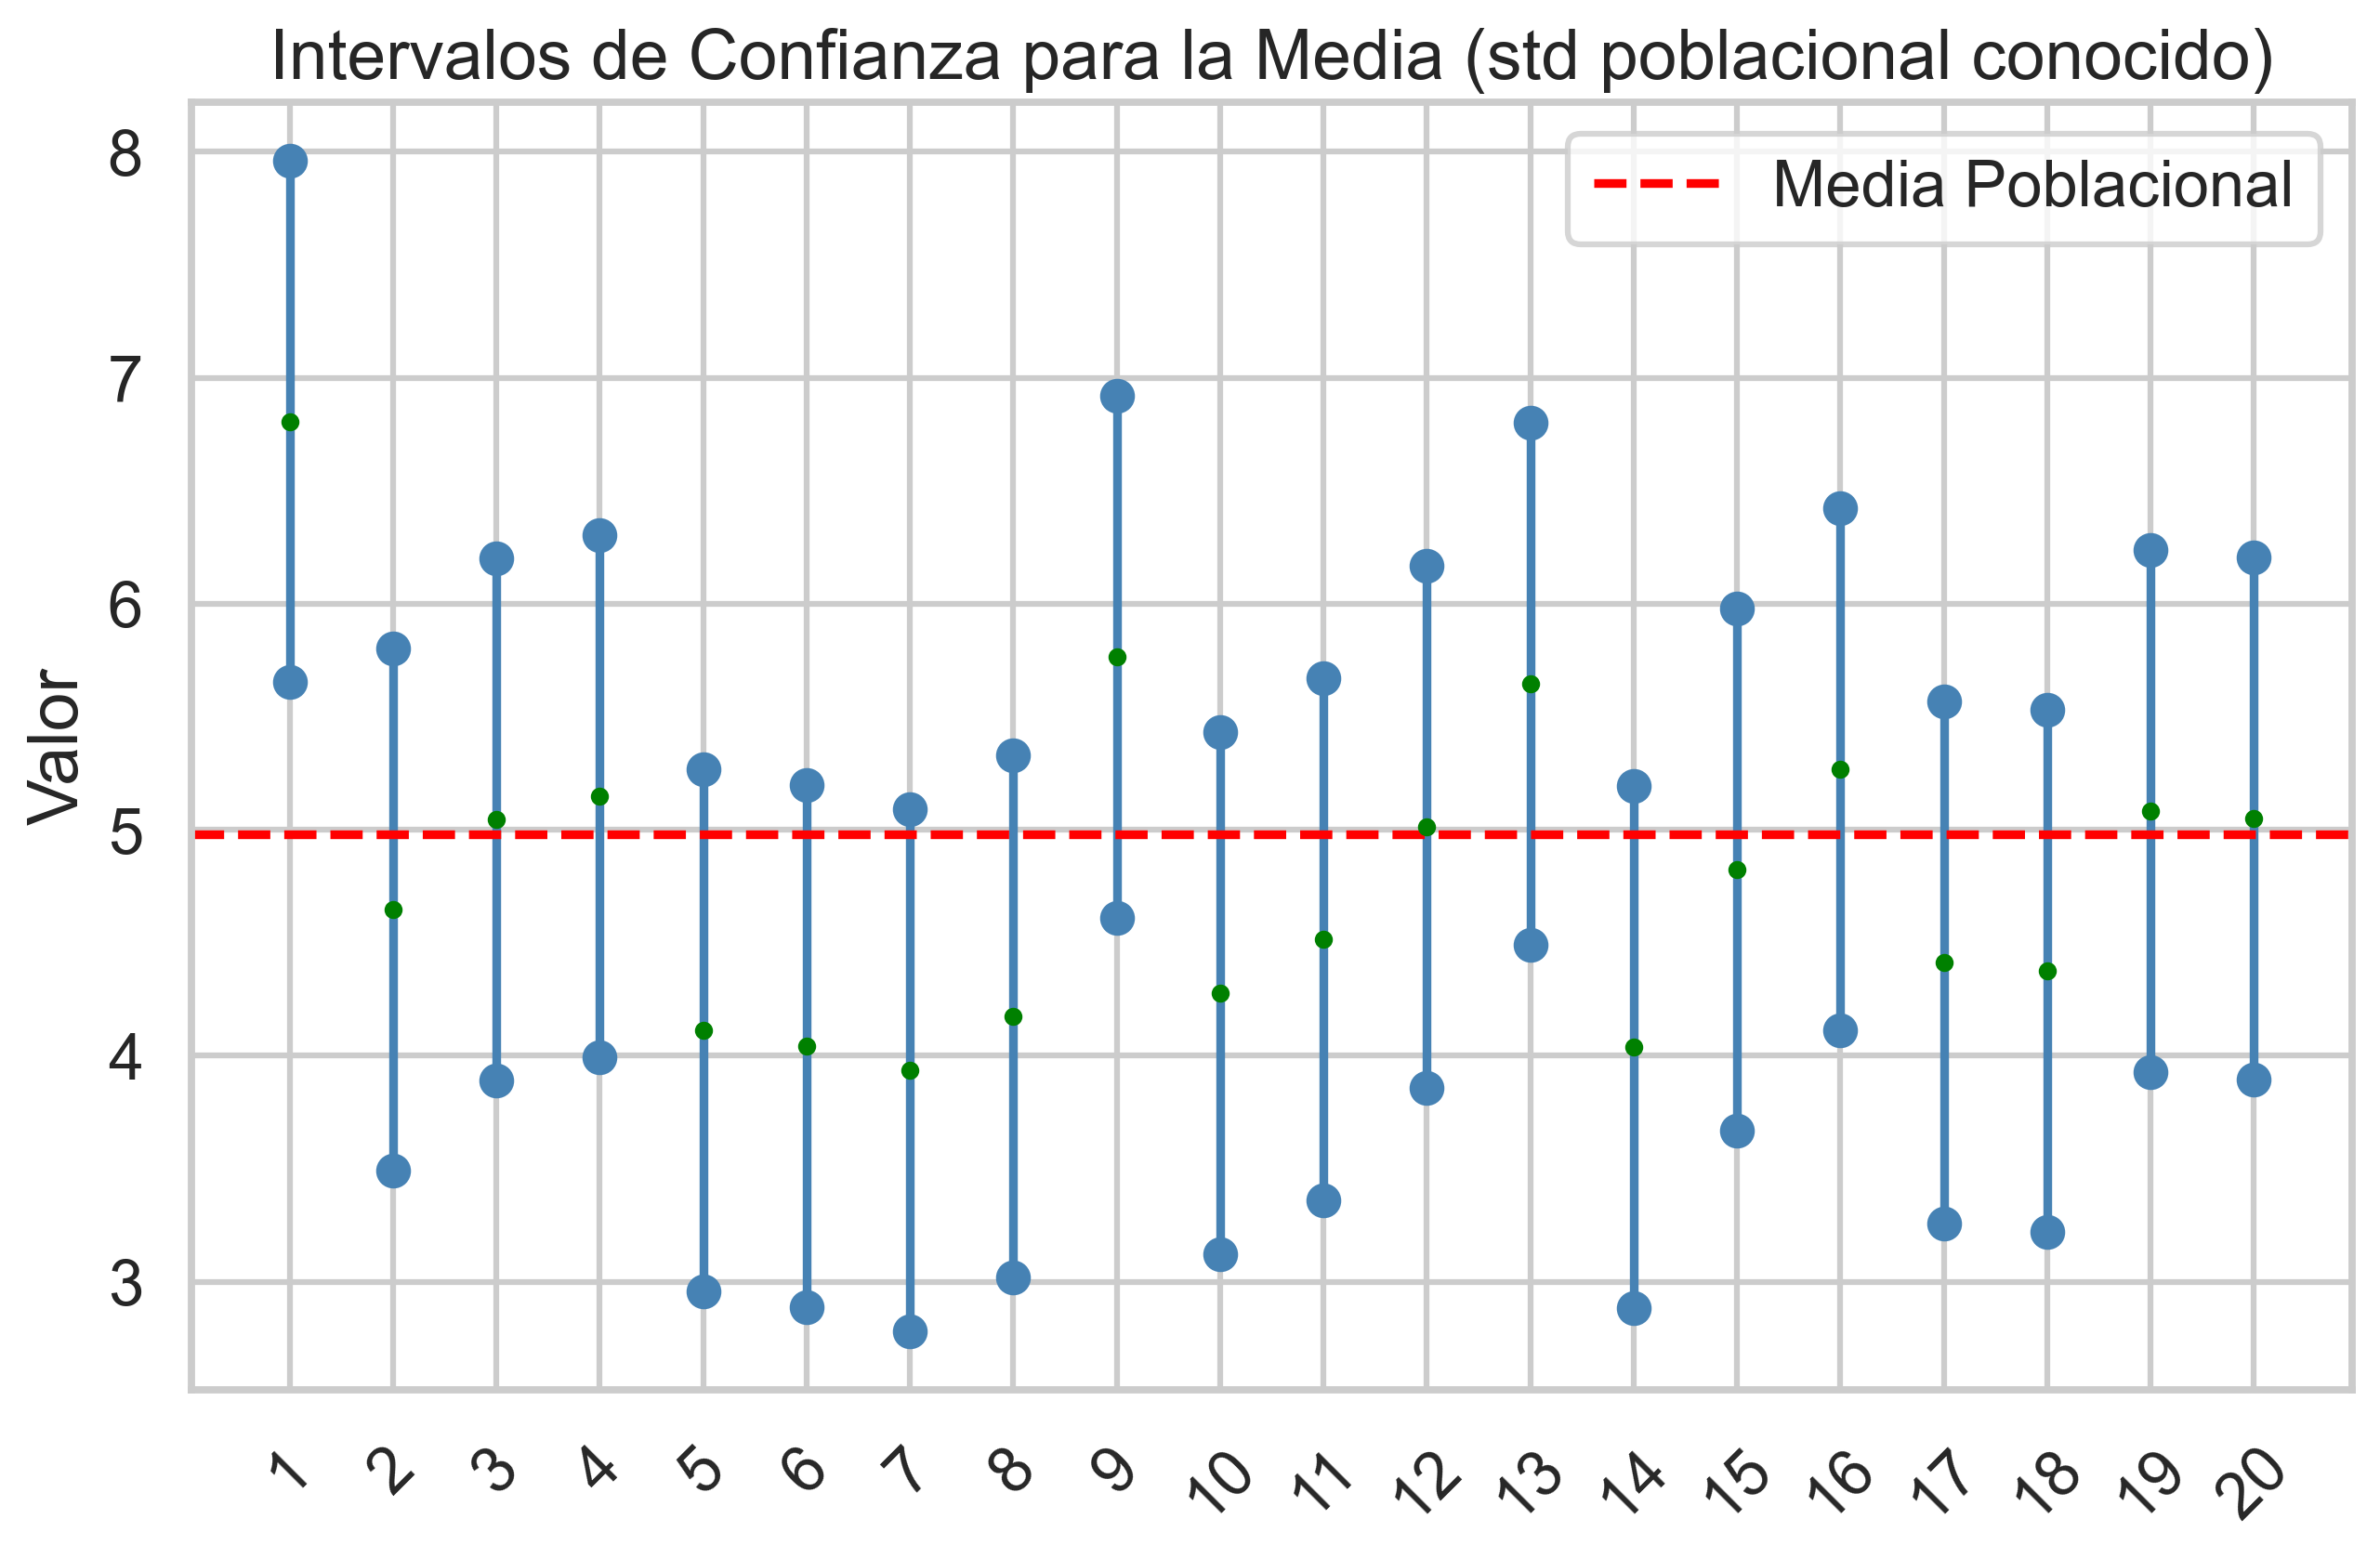

In [57]:
# intervalos de confianza
np.random.seed(42)  # Para reproducibilidad 
poblacion = np.random.exponential(scale=5, size=100000)  # Población con distribución exponencial (no normal)
std_poblacion = np.std(poblacion)  # Desviación estándar de la población <- conocida
# diferentes intervalos de confianza

intevalos = []
# intervalo del 90%
alpha = 0.10
z_critico = stats.norm.ppf(1 - alpha/2)  # z crítico para el intervalo del 90% z_alpha/2

for _ in range(20): # generamos 20 intervalos
    muestra = np.random.choice(poblacion, size=50)  # muestra aleatoria de tamaño 50
    media_muestral = np.mean(muestra)
    error_estandar = std_poblacion / np.sqrt(len(muestra))
    lb = media_muestral - z_critico * error_estandar
    ub = media_muestral + z_critico * error_estandar
    intevalos.append((lb, ub, media_muestral))

# Visualizamos los intervalos
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
for i, (lb, ub, media) in enumerate(intevalos):
    ax.plot([i, i], [lb, ub], color='steelblue', marker='o', markersize=8)
    ax.scatter(i, media, color='green', s = 10, zorder=5)  # media muestral como punto rojo
ax.axhline(np.mean(poblacion), color='red', linestyle='--', label='Media Poblacional')
ax.set_xticks(range(len(intevalos)))
ax.set_xticklabels([f'{i+1}' for i in range(len(intevalos))], rotation=45)
ax.set_ylabel('Valor')
ax.legend()
ax.set_title('Intervalos de Confianza para la Media (std poblacional conocido)')


Notemos que no siempre los intervalos son los mismos. Es más, existen casos en los que la media poblacional no es capturada por estos intervalos. Por ello, la definición dada es correcta, existe una probabilidad de no capturar el parámetro poblacional con el método.

En el caso de no conocer la varianza poblacional se utiliza la distribución t para modelar la población.

> Sea $X_1, X_2, ..., X_n$ una muestra aleatoria de una distribución normal con media $\mu$ desconocida y varianza $\sigma^2$ también desconocida. En este caso, la variable aleatoria
>$$ T = \frac{\overline{X} - \mu}{S/\sqrt{n}}$$
> sigue una distribución $t$ con n-1 grados de libertad.

De la misma forma de antes, es posible estimar los intervalos de confianza para la media, pero ahora sin conocer la varianza poblacional, esta se construye como:

> **Intervalo de Confianza para la Media, Varianza Desconocida**
>
> Si $\bar{x}$ y $s$ son la media y la desviación estándar de una muestra aleatoria de una distribución normal con varianza desconocida $\sigma^2$, un IC del $100(1-\alpha)\%$ para $\mu$ está dado por
>
> $$\bar{x} - t_{\alpha/2,\, n-1}\, s/\sqrt{n} \leq \mu \leq \bar{x} + t_{\alpha/2,\, n-1}\, s/\sqrt{n}$$
>
> donde $t_{\alpha/2,\, n-1}$ es el percentil superior $100\alpha/2$ de la distribución $t$ con $n-1$ grados de libertad.

La única condicion que aparece en este caso, es que la distribución debe ser normal.

Text(0.5, 1.0, 'Intervalos de Confianza para la Media (std poblacional desconocido)')

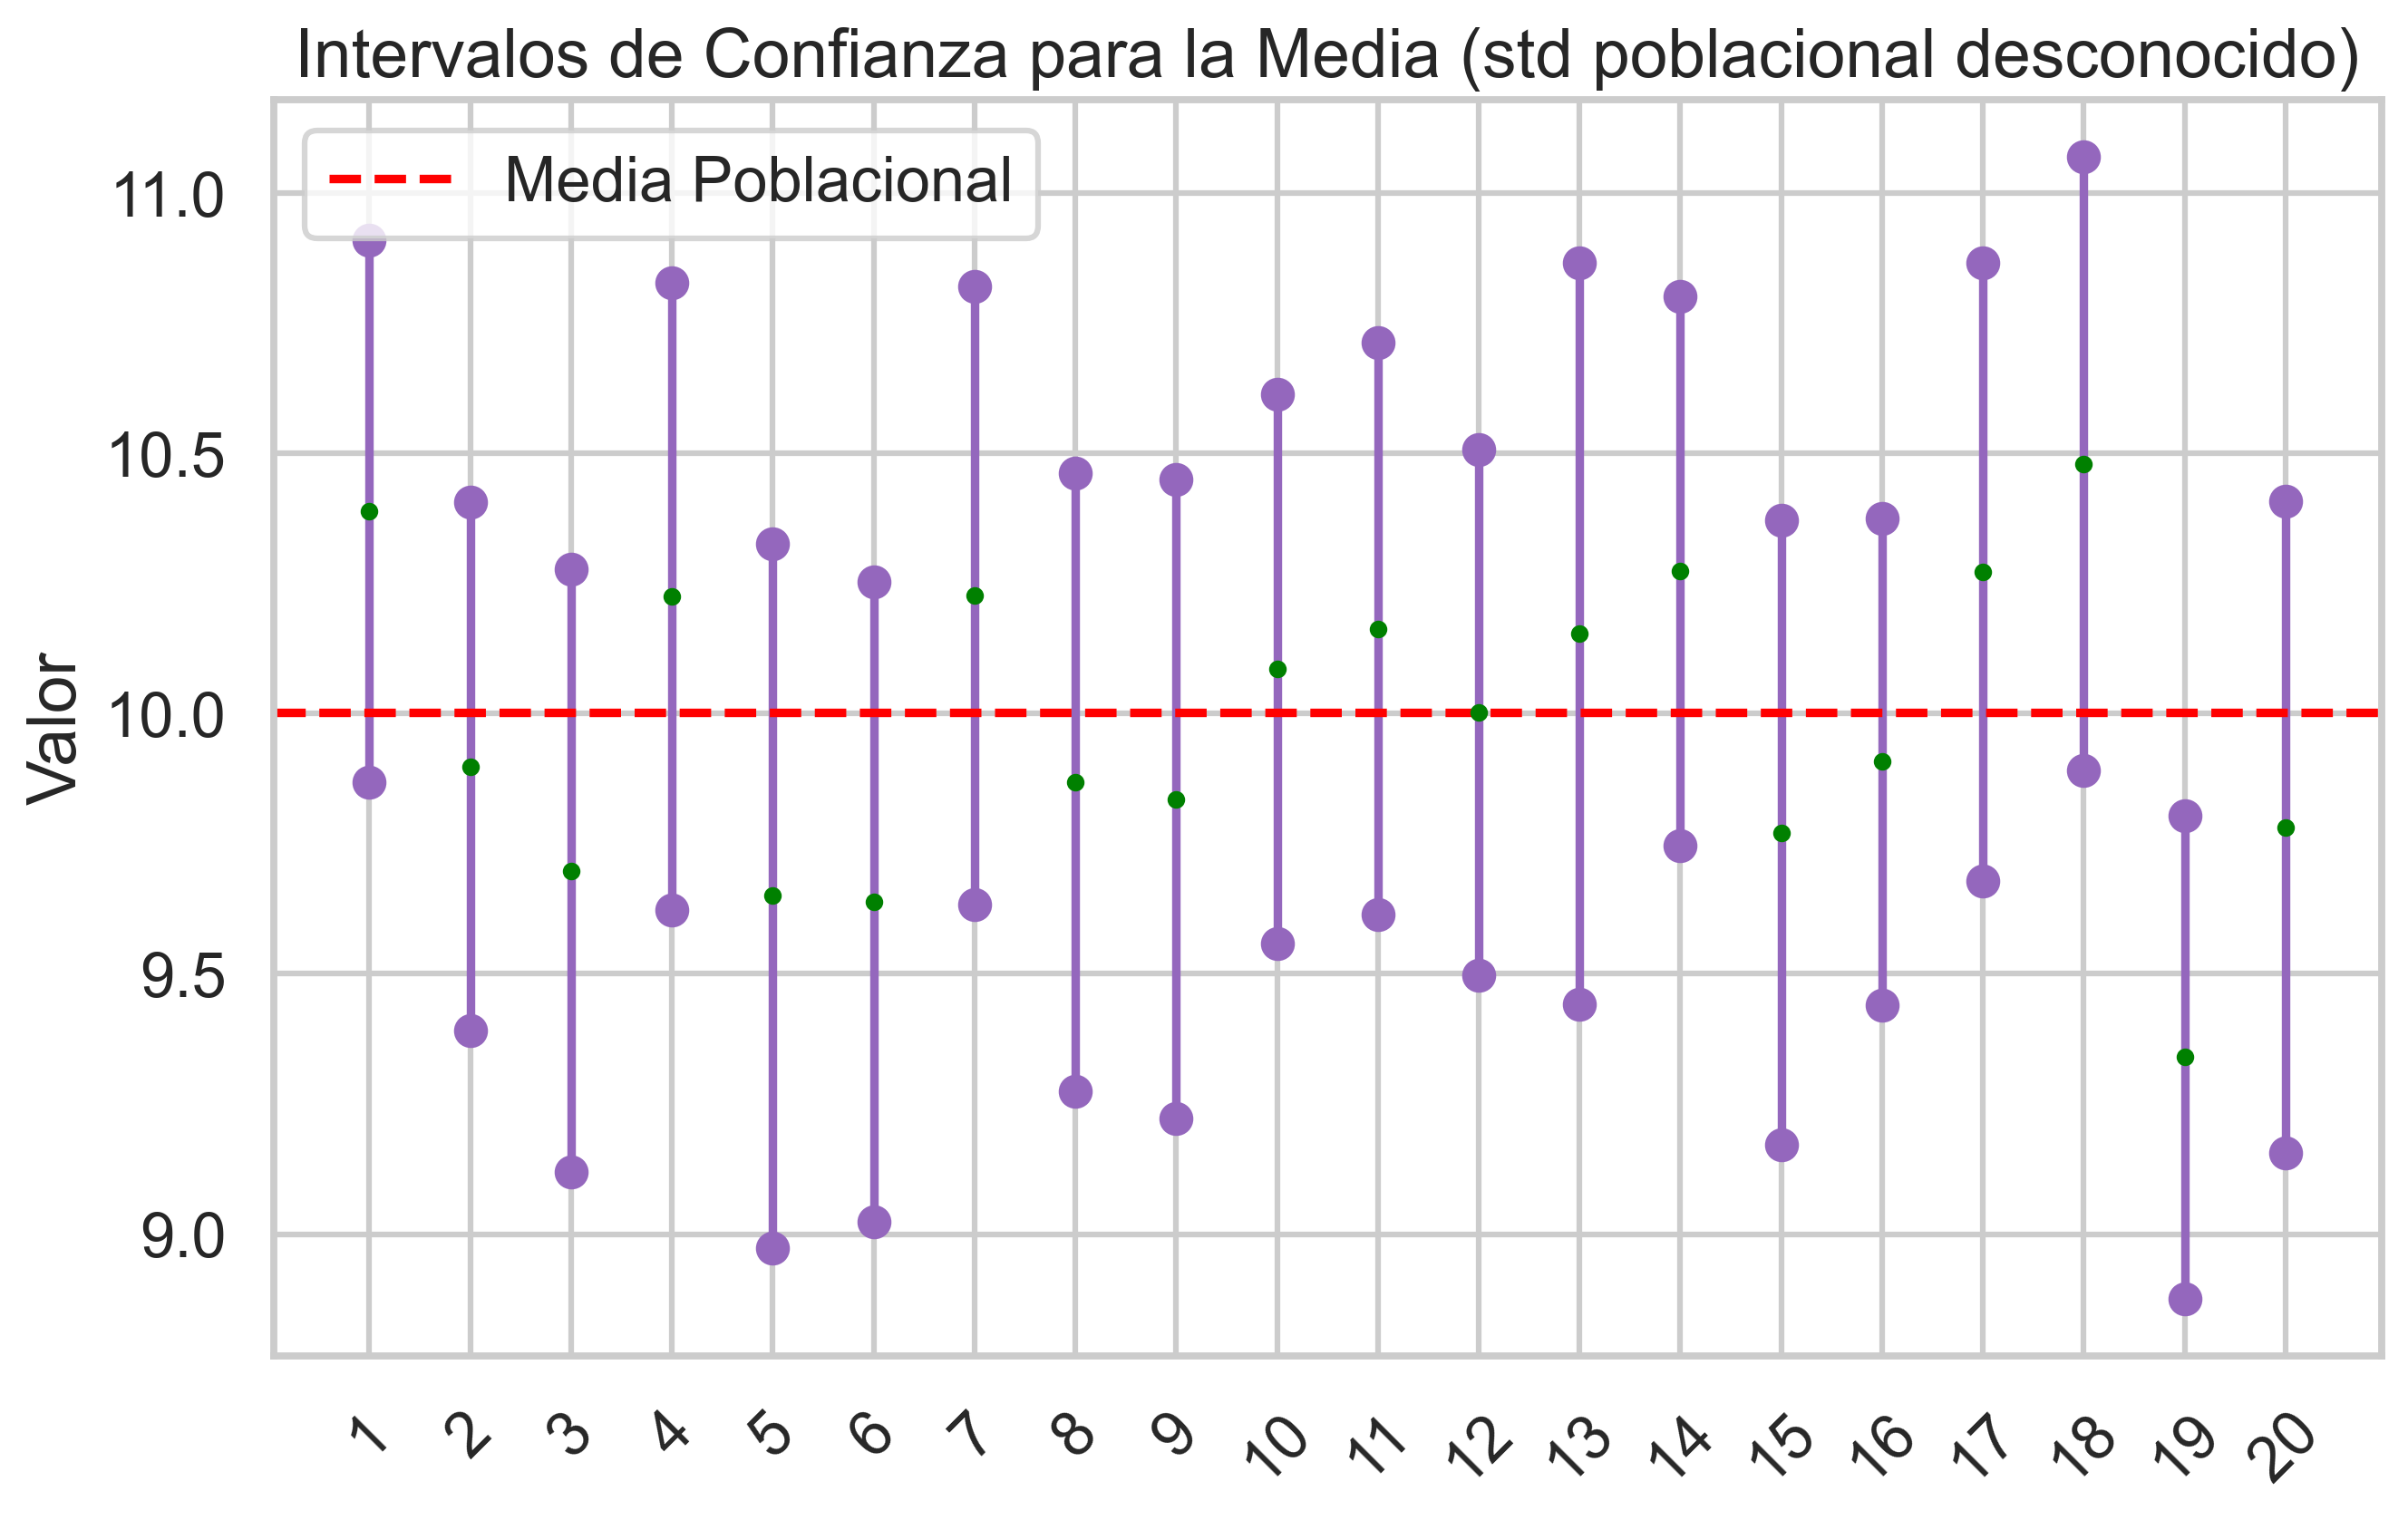

In [58]:
# intervalos de confianza para la media con distribución normal
np.random.seed(42)  # Para reproducibilidad
poblacion_normal = np.random.normal(loc=10, scale=2, size=100000)  # Población con distribución normal

# intervalos para la media con varianza desconocida (t-student)
intevalos_t = []
alpha = 0.05
n_muestral = 50
t_critico = stats.t.ppf(1 - alpha/2, df=n_muestral-1)  # t crítico para el intervalo del 95% con 49 grados de libertad
for _ in range(20): # generamos 20 intervalos
    muestra = np.random.choice(poblacion_normal, size=n_muestral)  # muestra aleatoria de tamaño 50
    media_muestral = np.mean(muestra)
    std_muestral = np.std(muestra, ddof=1)  # desviación estándar muestral
    error_estandar = std_muestral / np.sqrt(len(muestra))
    lb = media_muestral - t_critico * error_estandar
    ub = media_muestral + t_critico * error_estandar
    intevalos_t.append((lb, ub, media_muestral))

# Visualizamos los intervalos t
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
for i, (lb, ub, media) in enumerate(intevalos_t):
    ax.plot([i, i], [lb, ub], color='tab:purple', marker='o', markersize=8)
    ax.scatter(i, media, color='green', s = 10, zorder=5)  # media muestral como punto verde
ax.axhline(np.mean(poblacion_normal), color='red', linestyle='--', label='Media Poblacional')
ax.set_xticks(range(len(intevalos_t)))
ax.set_xticklabels([f'{i+1}' for i in range(len(intevalos_t))], rotation=45)
ax.set_ylabel('Valor')
ax.legend()
ax.set_title('Intervalos de Confianza para la Media (std poblacional desconocido)')

La única condición en este caso, es que la distribución de la muestra debe ser *casi* normal.

### Intervalo de confianza para la varianza de una distribución estandar

Previamente analizamos el caso cuando queremos estimar los intervalos para la media. Otros casos es cuando queremos estimar los intervalos de confianza para la varianza de una población, en este caso es necesario utilizar la siguiente distribución:

> **Distribución $\chi^2$**
>
> Sea $X_1, X_2, \ldots, X_n$ una muestra aleatoria de una distribución normal con media $\mu$ y varianza $\sigma^2$, y sea $S^2$ la varianza muestral. Entonces la variable aleatoria
>
> $$\chi^2 = \frac{(n-1)\,S^2}{\sigma^2}$$
>
> tiene una distribución chi-cuadrado ($\chi^2$) con $n-1$ grados de libertad.

De esta manera, es posible construir los siguientes intervalos de confianza para la varianza:



> **Intervalo de Confianza para la Varianza**
>
> Si $s^2$ es la varianza muestral de una muestra aleatoria de $n$ observaciones de una distribución normal con varianza desconocida $\sigma^2$, un IC del $100(1-\alpha)\%$ para $\sigma^2$ está dado por
>
> $$\frac{(n-1)s^2}{\chi^2_{\alpha/2,\, n-1}} \leq \sigma^2 \leq \frac{(n-1)s^2}{\chi^2_{1-\alpha/2,\, n-1}}$$
>
> donde $\chi^2_{\alpha/2,\, n-1}$ y $\chi^2_{1-\alpha/2,\, n-1}$ son los percentiles superior e inferior $100\alpha/2$ de la distribución chi-cuadrado con $n-1$ grados de libertad, respectivamente. Un intervalo de confianza para $\sigma$ se obtiene tomando la raíz cuadrada de ambos límites.

También es posible contruir únicamente los límites inferiores o superiores.

> **Límites de Confianza Unilaterales para la Varianza**
>
> Los límites de confianza inferior y superior del $100(1-\alpha)\%$ para $\sigma^2$ son, respectivamente:
>
> $$\frac{(n-1)s^2}{\chi^2_{\alpha,\, n-1}} \leq \sigma^2 \qquad \text{y} \qquad \sigma^2 \leq \frac{(n-1)s^2}{\chi^2_{1-\alpha,\, n-1}}$$

Text(0.5, 1.0, 'Intervalos de Confianza para la Varianza (Chi-cuadrado)')

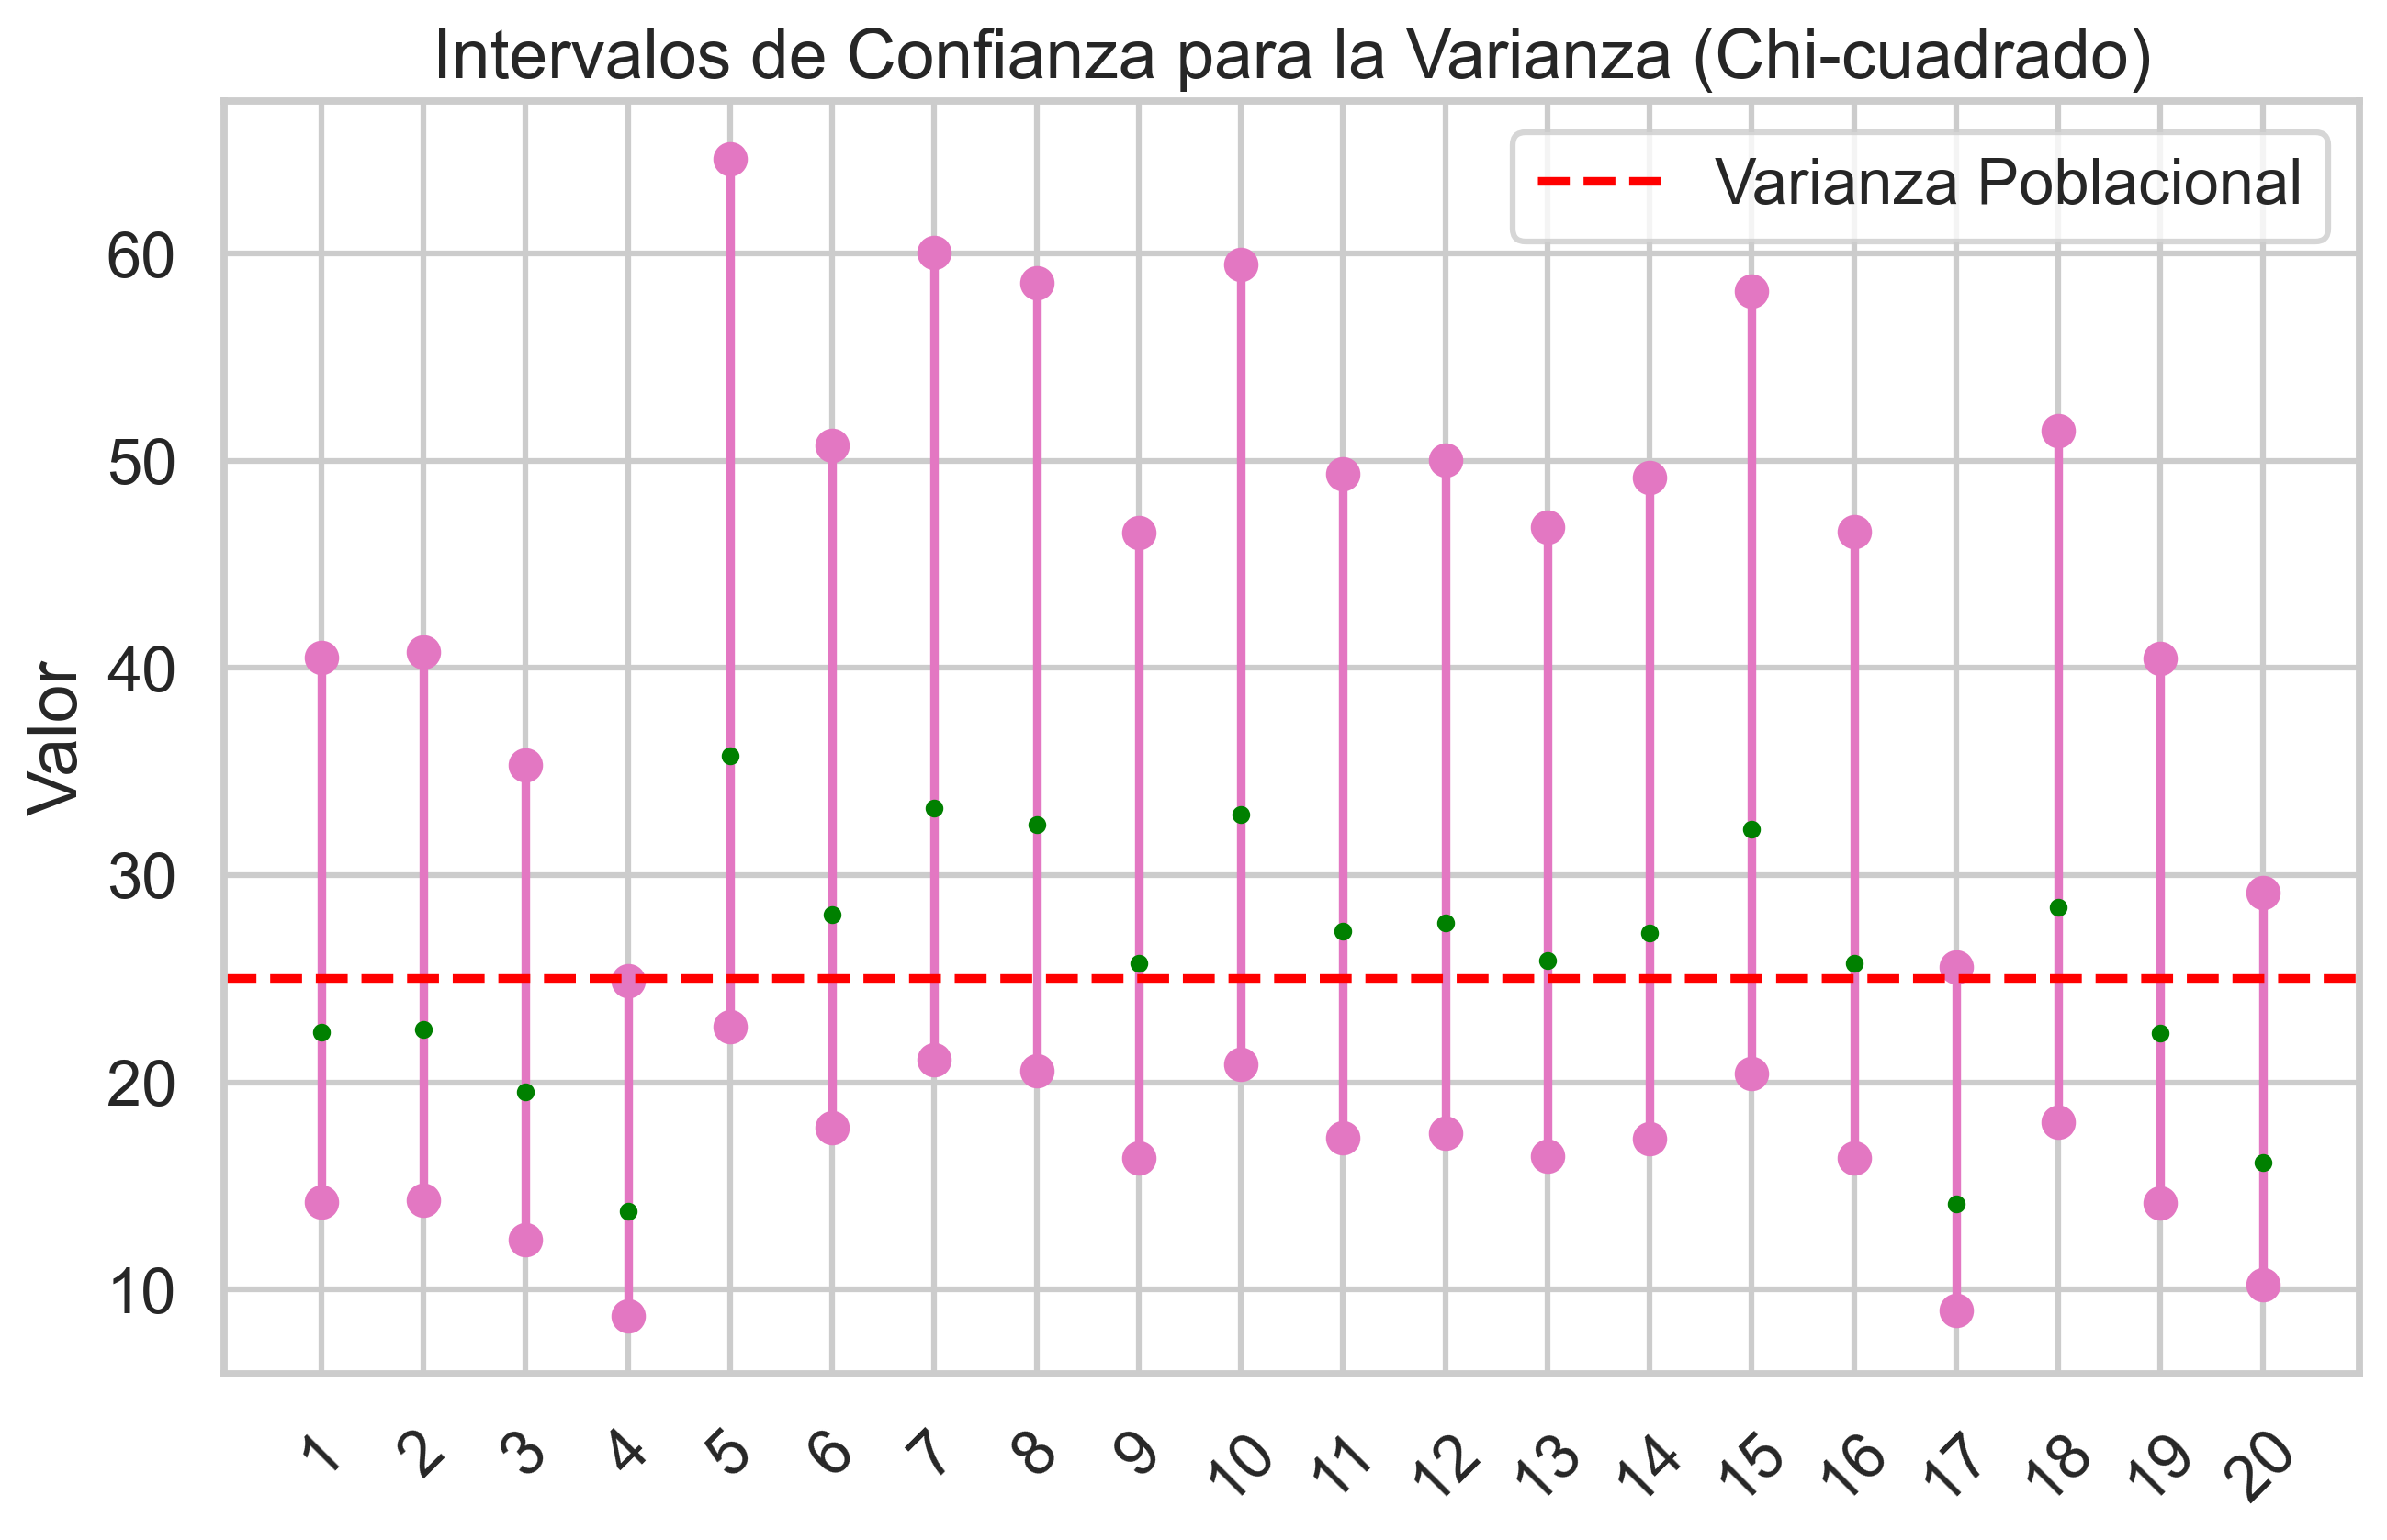

In [59]:
# IC para varianza
np.random.seed(42)  # Para reproducibilidad
poblacion_chi2 = np.random.normal(loc=10, scale=5, size=100000)  # Población con distribución normal (varianza poblacional = 25)

intevalos_varianza = []
alpha = 0.05
n_muestral = 30
for _ in range(20): # generamos 20 intervalos
    muestra = np.random.choice(poblacion_chi2, size=n_muestral)  # muestra aleatoria de tamaño 30
    var_muestral = np.var(muestra, ddof=1)  # varianza muestral
    chi2_inf = stats.chi2.ppf(alpha/2, df=n_muestral-1)  # chi2 crítico inferior
    chi2_sup = stats.chi2.ppf(1 - alpha/2, df=n_muestral-1)  # chi2 crítico superior
    lb = (n_muestral - 1) * var_muestral / chi2_sup
    ub = (n_muestral - 1) * var_muestral / chi2_inf
    intevalos_varianza.append((lb, ub, var_muestral))
    
# Visualizamos los intervalos para la varianza
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
for i, (lb, ub, var) in enumerate(intevalos_varianza):
    ax.plot([i, i], [lb, ub], color='tab:pink', marker='o', markersize=8)
    ax.scatter(i, var, color='green', s = 10, zorder=5)  # varianza muestral como punto verde
ax.axhline(np.var(poblacion_chi2), color='red', linestyle='--', label='Varianza Poblacional')
ax.set_xticks(range(len(intevalos_varianza)))
ax.set_xticklabels([f'{i+1}' for i in range(len(intevalos_varianza))], rotation=45)
ax.set_ylabel('Valor')
ax.legend()
ax.set_title('Intervalos de Confianza para la Varianza (Chi-cuadrado)')

De nuevo, la condición en este caso es que la muestra sea casi normal.

### Intervalo de confianza para la proporción poblacional

Para una muestra con una gran cantidad de valores. La proporción de la muestra, que típicamente se modela mediante una distribución binomial, tiene a una distribución normal (puede verificarse computacionalmente).

Es decir:
> **Aproximación Normal para una Proporción Binomial**
>
> Si $n$ es grande, la distribución de
>
> $$Z = \frac{X - np}{\sqrt{np(1-p)}} = \frac{\hat{P} - p}{\sqrt{\dfrac{p(1-p)}{n}}}$$
>
> es aproximadamente normal estándar.

Lo que nos permite construir los siguientes intervalos de confianza para la proporción poblacional:
> **Intervalo de Confianza Aproximado para una Proporción Binomial**
>
> Si $\hat{p}$ es la proporción de observaciones en una muestra aleatoria de tamaño $n$ que pertenece a una clase de interés, un IC aproximado del $100(1-\alpha)\%$ para la proporción poblacional $p$ está dado por
>
> $$\hat{p} - z_{\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}} \leq p \leq \hat{p} + z_{\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$
>
> donde $z_{\alpha/2}$ es el percentil superior $\alpha/2$ de la distribución normal estándar.


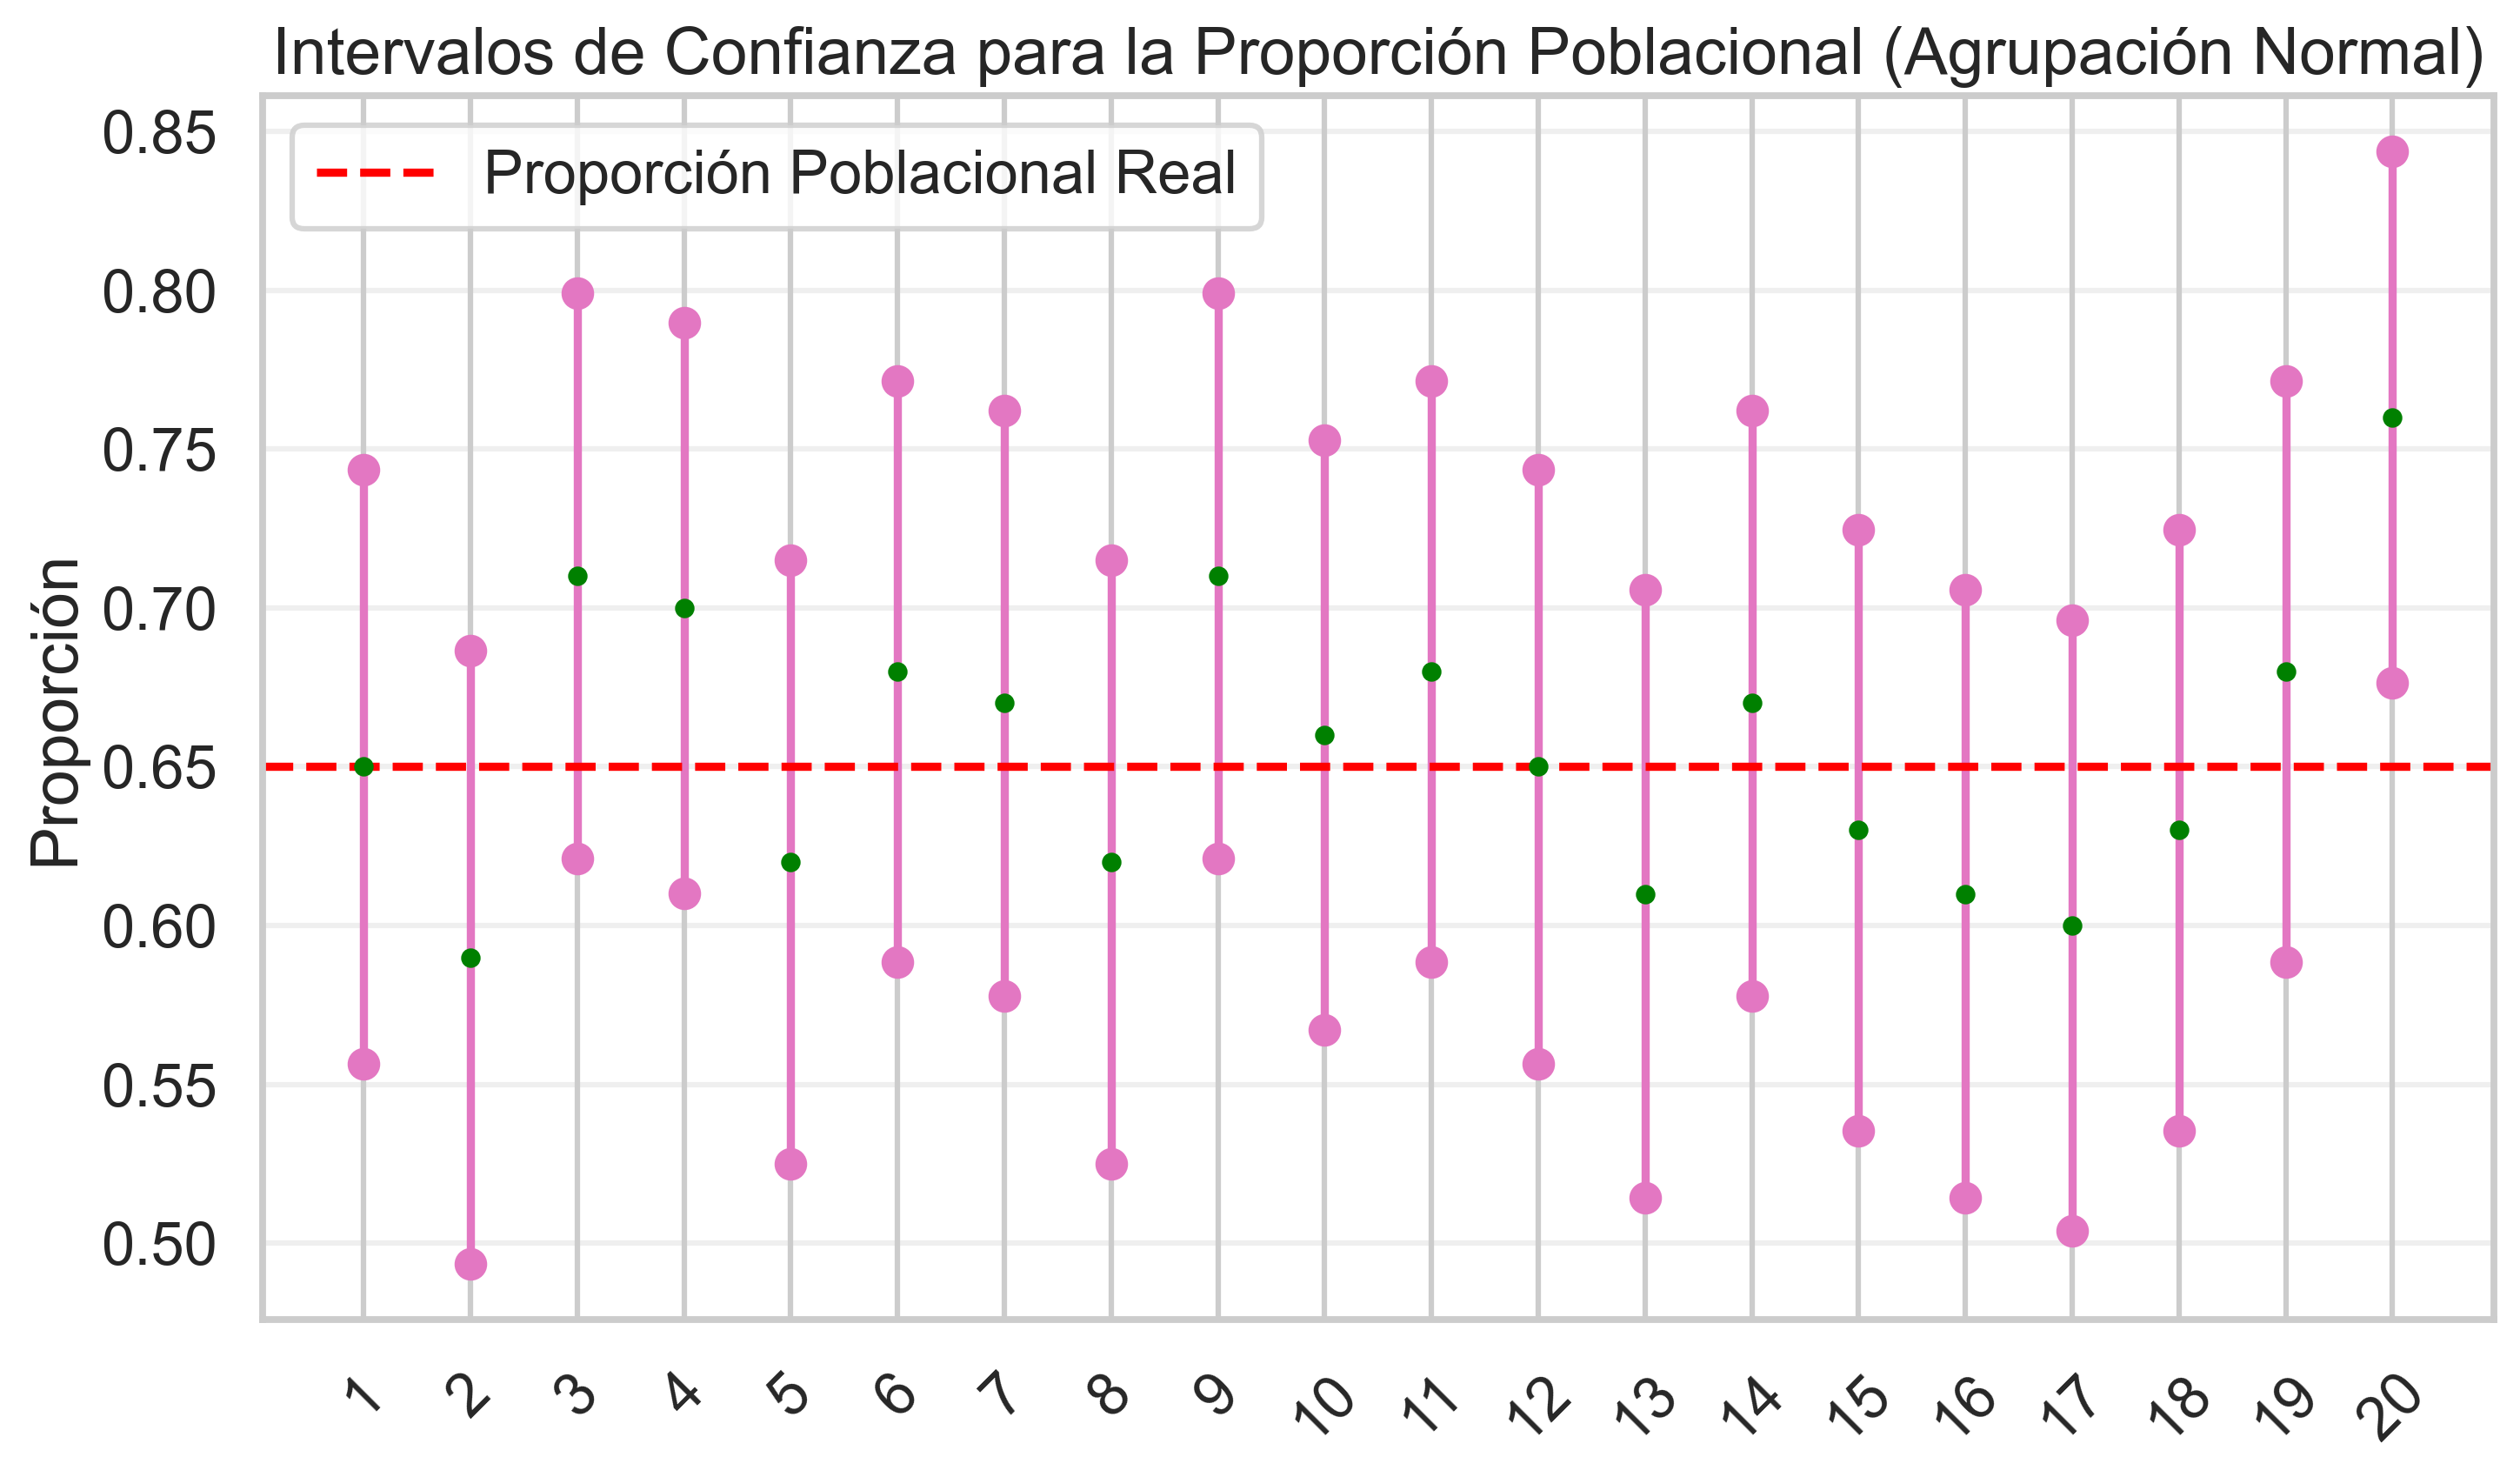

In [60]:
# IC para la proporción poblacional
np.random.seed(42)  # Para reproducibilidad

p_poblacional_real = 0.65  # Proporción poblacional verdadera (65%)
# Población binomial (0 y 1, donde 1 representa el "éxito" o característica de interés)
poblacion_prop = np.random.binomial(n=1, p=p_poblacional_real, size=100000)

intervalos_proporcion = []
alpha = 0.05
n_muestral = 100 # Se usa un n mayor (100) para asegurar que la aproximación normal sea válida

for _ in range(20): # generamos 20 intervalos
    muestra = np.random.choice(poblacion_prop, size=n_muestral)  # muestra aleatoria
    p_muestral = np.mean(muestra)  # proporción muestral
    # Se usa la distribución Normal para proporciones con n grande
    z_critico = stats.norm.ppf(1 - alpha/2)  # z crítico superior
    # Error estándar para la proporción
    error_estandar = np.sqrt((p_muestral * (1 - p_muestral)) / n_muestral)
    # Limites
    lb = p_muestral - z_critico * error_estandar
    ub = p_muestral + z_critico * error_estandar
    intervalos_proporcion.append((lb, ub, p_muestral))
    
# Visualizamos los intervalos para la proporción
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
for i, (lb, ub, p_m) in enumerate(intervalos_proporcion):
    ax.plot([i, i], [lb, ub], color='tab:pink', marker='o', markersize=8)
    ax.scatter(i, p_m, color='green', s = 15, zorder=5)  # proporción muestral como punto verde
    
ax.axhline(p_poblacional_real, color='red', linestyle='--', label='Proporción Poblacional Real')

ax.set_xticks(range(len(intervalos_proporcion)))
ax.set_xticklabels([f'{i+1}' for i in range(len(intervalos_proporcion))], rotation=45)
ax.set_ylabel('Proporción')
ax.legend()
ax.set_title('Intervalos de Confianza para la Proporción Poblacional (Agrupación Normal)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()